# <b>Loan Default Risk Prediction</b>

## <b>Exploratory Data Analysis (EDA)</b>

### <b>Session 1: Dataset Overview</b>

**Objective:**

The objective of this session is to understand the overall structure of the dataset before performing any preprocessing or feature engineering.

In this session, we will:

- Load the dataset using the Data Ingestion Pipeline
- Inspect the dataset structure
- Understand the dimensions of the dataset
- Identify numerical and categorical features
- Check missing values and duplicate records

#### <b>Step 1: Import Required Libraries</b>

We begin by importing the required libraries for data manipulation and loading the dataset.

Notice that we are **not using `pd.read_csv()` directly**. Instead, we load the data through our production Data Ingestion component.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.components.data_ingestion import DataIngestion

#### <b>Step 2: Load Dataset</b>

The dataset is loaded using the Data Ingestion pipeline.

Using a centralized ingestion component improves maintainability because any future change in the data source only needs to be updated in one place.

In [2]:
ingestion  = DataIngestion()
df = ingestion.load_data()

[2026-07-23 18:11:55,020] INFO - loan_default_project - Loading dataset from: D:\MachineLearningProjects\Loan_Default_Risk_Prediction\data\raw\application_train.csv
[2026-07-23 18:12:04,319] INFO - loan_default_project - Dataset loaded successfully with shape: (307511, 122)


#### <b>Step 3: Display First Five Records</b>

The `head()` function displays the first five rows of the dataset.

This helps us verify:

- Column names
- Data types
- Sample values
- Overall dataset structure

Instead of printing the complete dataset, which contains more than 300,000 records, we inspect only a small sample.

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


##### <b>Observation</b>

- The dataset contains customer demographic and financial information.
- Each row represents one loan application.
- The target variable is **TARGET**.
- The dataset contains both numerical and categorical variables.

#### <b>Step 4: Check Dataset Shape</b>

The shape of the dataset tells us the number of rows and columns available for analysis.

In [4]:
df.shape

(307511, 122)

##### <b>Observation</b>

The dataset contains:

- **307,511 rows**
- **122 columns**

This indicates a relatively large dataset with many features that will require preprocessing before model training.

#### <b>Step 5: Dataset Information</b>

The `info()` function provides:

- Number of rows
- Number of columns
- Non-null values
- Data types
- Memory usage

This is one of the first commands every Data Scientist runs before starting EDA.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


##### <b>Observation</b>

From the dataset information we observe:

- Multiple columns contain missing values.
- Both numerical and categorical features are present.
- Most numerical columns are stored as `float64` or `int64`.
- Several categorical columns are stored as `object`.

#### <b>Step 6: Statistical Summary</b>

The `describe()` function summarizes the numerical features.

It provides:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


##### <b>Observation</b>

The statistical summary helps us identify:

- Features with large ranges
- Possible outliers
- Skewed distributions
- Missing values (through reduced count)

#### <b>Step 7: Missing Value Analysis</b>

Before cleaning the data, we identify which columns contain missing values.

This helps us decide the appropriate imputation strategy during preprocessing.

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

##### <b>Observation</b>

Several columns contain a high percentage of missing values.

These columns will require careful handling during the feature engineering stage.

At this point, we only identify missing values—we do not remove or impute them.

#### <b>Session 1 Summary</b>

In this session we:

- Successfully loaded the dataset
- Understood the dataset dimensions
- Explored the dataset structure
- Identified numerical and categorical features
- Checked duplicate records
- Identified missing values
- Generated initial business observations

The dataset is now ready for deeper exploratory analysis in the next session.

### <b>Session 2: Target Variable Analysis</b>

**Objective**

The objective of this session is to understand the distribution of the target variable and determine whether the dataset is balanced or imbalanced.

The target variable is `TARGET`, where:

- `0` represents a customer who repaid the loan or did not experience payment difficulty.
- `1` represents a customer who defaulted or experienced payment difficulty.

Target analysis is important because class distribution directly affects model training, evaluation metrics, and sampling strategies.

#### <b>Business Context</b>

The organization wants to identify customers who are likely to default before approving a loan.

In this business problem:

- Correctly identifying a defaulter helps reduce financial loss.
- Missing an actual defaulter can be costly.
- Incorrectly classifying a reliable customer as risky may result in additional verification or rejection of a potentially profitable customer.

Therefore, understanding the number of defaulters and non-defaulters is essential before building the classification model.

#### <b>Step 1: Verify the Target Column</b>

Before analyzing the target variable, we first confirm that the `TARGET` column is present in the dataset.

This prevents the analysis from continuing with an incomplete or incorrect dataset.

In [8]:
target_column = "TARGET"
if target_column not in df.columns:
    raise ValueError(f"Target Column `{target_column}` is missing from the dataset.")
print(f"Target Column '{target_column}' is present.")

Target Column 'TARGET' is present.


#### <b>Step 2: Check Unique Values in the Target Column</b>

A binary classification target should contain two valid classes.

For this project, the expected values are:

- `0`: No default
- `1`: Default

Checking unique values also helps identify unexpected labels or data-quality problems.

In [9]:
target_values = sorted(df[target_column].dropna().unique().tolist())
print(f"Unique target values: {target_values}")

Unique target values: [0, 1]


##### <b>Observation</b>

The `TARGET` column contains two unique values: `0` and `1`.

Therefore, this is a binary classification problem.

No unexpected target labels were identified.

#### <b>Step 3: Check Missing Values in the Target Column</b>

The target column must contain valid labels for model training.

Rows with a missing target cannot be directly used in supervised learning because the expected outcome is unknown.

In [10]:
target_missing_count = df[target_column].isnull().sum()
target_missing_percentage = (
    target_missing_count / len(df)
) * 100

print("Missing target values:", target_missing_count)
print(f"Missing target percentage: {target_missing_percentage:.2f}%")

Missing target values: 0
Missing target percentage: 0.00%


##### <b>Observation</b>

The `TARGET` column does not contain any missing values.

This means every record has a known loan repayment outcome and can potentially be used for supervised model training.

#### <b>Step 4: Calculate the Number of Records in Each Target Class</b>

The `value_counts()` function calculates how many customers belong to each target category.

This helps us compare the number of non-default and default cases.

In [11]:
target_counts = df[target_column].value_counts().sort_index()
print(target_counts)

TARGET
0    282686
1     24825
Name: count, dtype: int64


##### <b>Observation</b>

The dataset contains approximately:

- **282,686 non-default customers**
- **24,825 default customers**

The number of customers who did not default is substantially higher than the number of customers who defaulted.

#### <b>Step 5: Calculate the Percentage Distribution of the Target</b>

Counts show the absolute number of records, while percentages make it easier to understand the relative distribution of each class.

In [12]:
target_percentage = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

print(target_percentage)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


##### <b>Observation</b>

Approximately:

- **91.93%** of customers belong to the non-default class.
- **8.07%** of customers belong to the default class.

The target classes are not equally distributed. The default class is significantly smaller than the non-default class.

#### <b>Step 6: Create a Target Distribution Summary</b>

A summary table combines target labels, customer counts, and class percentages in a clear and readable format.

In [13]:
target_summary = pd.DataFrame({
    "Target": target_counts.index,
    "Customer_Count": target_counts.values,
    "Percentage": target_percentage.values
})

target_summary['Class_Label'] = target_summary['Target'].map(
    {
        0: "No Default",
        1: "Default"
    }
)

target_summary = target_summary[
    [
        "Target",
        "Class_Label",
        "Customer_Count",
        "Percentage"
    ]
]

print(target_summary)

   Target Class_Label  Customer_Count  Percentage
0       0  No Default          282686       91.93
1       1     Default           24825        8.07


#### <b>Step 7: Visualize the Target Distribution</b>

A bar chart allows us to visually compare the size of the two target classes.

A large difference between the bars indicates class imbalance.

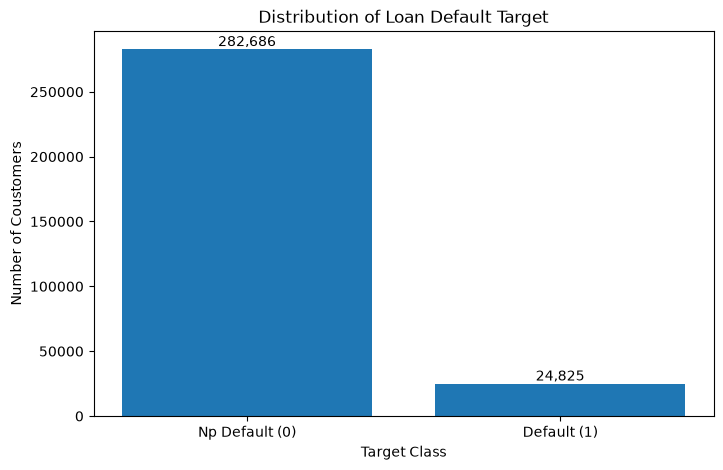

In [14]:
class_labels = ["Np Default (0)", "Default (1)"]
fig,ax = plt.subplots(figsize=(8,5))
bars = ax.bar(class_labels, target_counts.values)
ax.set_title("Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Number of Coustomers")

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.show()

##### <b>Observation</b>

The non-default class is much larger than the default class.

This confirms that the dataset is imbalanced.

A model trained without considering this imbalance may become biased toward predicting the majority class.

#### <b>Step 8: Visualize the Percentage of Each Target Class</b>

The following chart shows the percentage contribution of each class.

This representation makes the degree of class imbalance easier to interpret.

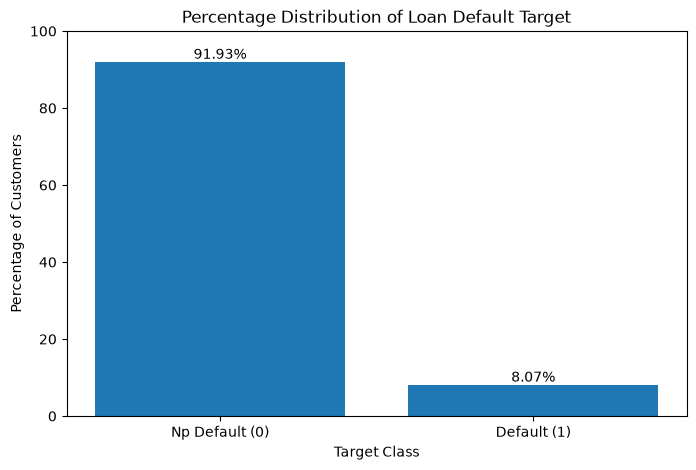

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    class_labels,
    target_percentage.values,
)

ax.set_title("Percentage Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Percentage of Customers")
ax.set_ylim(0, 100)

for bar, percentage in zip(bars, target_percentage.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.show()

#### <b>Step 9: Calculate the Class-Imbalance Ratio</b>

The imbalance ratio compares the number of majority-class records with the number of minority-class records.

It helps quantify how much larger the non-default class is than the default class.

In [16]:
non_default_count = target_counts.get(0,0)
default_count = target_counts.get(1,0)

if default_count==0:
    raise ValueError(
        "The default class contains no records. "
        "The imbalance ratio can't be calculated."
    )
imbalance_ratio = non_default_count/default_count
print("Class imbalance ratio: ", f"{imbalance_ratio:.2f}:1")

Class imbalance ratio:  11.39:1


##### <b>Observation</b>

For approximately every one customer who defaults, there are more than eleven customers who do not default.

This is a significant class imbalance and must be considered during:

- Train-test splitting
- Model training
- Model evaluation
- Threshold selection
- Sampling or class-weight decisions

#### <b>Step 10: Why Accuracy Can Be Misleading</b>

Suppose a model predicts every customer as `0`, meaning no customer will default.

Because approximately 91.93% of the records belong to class `0`, this model would achieve approximately 91.93% accuracy.

However, it would fail to identify every actual defaulter.

Therefore, high accuracy does not necessarily mean that the model is useful for the business.

In [17]:
majority_class_accuracy = (
    non_default_count / len(df)
) * 100

print(
    "Accuracy obtained by predicting every customer as non-default:",
    f"{majority_class_accuracy:.2f}%",
)

Accuracy obtained by predicting every customer as non-default: 91.93%


##### <b>Business Interpretation</b>

A model that always predicts `No Default` would achieve high accuracy but would detect none of the actual defaulters.

Such a model would expose the company to financial losses because risky customers could still receive loans.

Therefore, accuracy alone should not be used as the primary model evaluation metric for this project.

#### <b>Step 11: Select Appropriate Evaluation Metrics</b>

Because the dataset is imbalanced, the model should be evaluated using metrics that measure performance on the minority class.

The following metrics will be important:

##### <b>Recall</b>

Recall measures how many actual defaulters are correctly detected.

A high recall means the model misses fewer risky customers.

##### <b>Precision</b>

Precision measures how many customers predicted as defaulters actually defaulted.

A high precision reduces unnecessary rejection or investigation of reliable customers.

##### <b>F1-Score</b>

F1-score balances precision and recall.

It is useful when both false positives and false negatives are important.

##### <b>ROC-AUC</b>

ROC-AUC measures the model's ability to rank default customers above non-default customers across different classification thresholds.

##### <b>PR-AUC</b>

Precision-Recall AUC is especially useful for imbalanced datasets because it focuses more directly on performance for the positive minority class.

##### <b>Metric Priority for This Project</b>

Recall will be an important metric because failing to detect an actual defaulter can cause financial loss.

However, maximizing recall without considering precision may result in too many reliable customers being classified as risky.

Therefore, the final model should balance:

- Recall
- Precision
- F1-score
- ROC-AUC
- Precision-Recall AUC

The final decision threshold should also be selected according to the business cost of false positives and false negatives.

#### <b>Step 12: Business Meaning of Classification Errors</b>

##### <b>False Positive</b>

The model predicts that a customer will default, but the customer would actually repay the loan.

Possible business consequence:

- A reliable customer may face additional verification.
- The loan may be rejected.
- The company may lose a profitable customer.

##### <b>False Negative</b>

The model predicts that a customer will repay the loan, but the customer actually defaults.

Possible business consequence:

- The company may approve a high-risk loan.
- The lender may experience financial loss.
- Recovery and collection costs may increase.

In loan default prediction, false negatives are generally considered especially costly because actual defaulters are missed.

#### <b>Step 13: Modeling Decisions Based on Target Distribution</b>

The target analysis suggests the following modeling decisions:

1. Use a stratified train-test split to preserve the target distribution.
2. Avoid evaluating the model using accuracy alone.
3. Compare recall, precision, F1-score, ROC-AUC, and PR-AUC.
4. Consider class-weighted algorithms.
5. Experiment with sampling techniques only on the training data.
6. Evaluate probability thresholds according to business cost.
7. Compare the model against a majority-class baseline.

##### <b>Important Note About Resampling</b>

Techniques such as SMOTE may be tested later, but they must only be applied to the training dataset.

Applying SMOTE before train-test splitting would create data leakage because synthetic information derived from the complete dataset could influence the test set.

We will compare multiple strategies instead of assuming that SMOTE is automatically the best solution:

- No resampling
- Class weights
- Random undersampling
- Random oversampling
- SMOTE
- Threshold tuning

#### <b>Business Insights</b>

1. Loan defaults represent only a small portion of all applications.
2. Most customers repay their loans, while approximately 8% experience payment difficulty.
3. A model that predicts every customer as non-default can still achieve more than 91% accuracy.
4. Accuracy alone would therefore provide a misleading view of model performance.
5. Missing an actual defaulter may cause direct financial loss.
6. Incorrectly identifying a reliable customer as risky may reduce business opportunities.
7. The final modeling strategy must balance risk reduction with customer approval opportunities.

#### <b>Session 2 Summary</b>

In this session, we:

- Verified the target column
- Confirmed that the problem is binary classification
- Checked missing values in the target
- Calculated target counts and percentages
- Visualized the target distribution
- Measured the class-imbalance ratio
- Demonstrated why accuracy can be misleading
- Identified suitable evaluation metrics
- Interpreted false positives and false negatives
- Defined initial modeling decisions

The dataset is imbalanced, with the default class representing approximately 8% of the observations.

The next session will focus on missing-value analysis across all input features.

### <b>Session 3: Missing-Value Analysis</b>

**Objective**

The objective of this session is to identify, measure, and interpret missing values in the loan application dataset.

Missing-value analysis is important because incomplete information can:

- Reduce the quality of model training
- Cause some machine-learning algorithms to fail
- Introduce bias when handled incorrectly
- Reveal useful business patterns
- Influence feature-selection and imputation decisions

In this session, we will analyze missing values without modifying the original dataset.

#### <b>Business Context</b>

Loan applications may contain missing values for several reasons.

For example:

- A customer may not own a house, car, or property.
- A particular document may not have been submitted.
- External credit-score information may not be available.
- Some fields may not apply to every customer.
- Data may have been lost or incorrectly recorded.

Therefore, a missing value does not always mean that the data is incorrect.

Before deciding how to handle missing values, we must understand their frequency, meaning, and relationship with the business problem.

#### <b>Step 1: Calculate the Total Number of Missing Values</b>

We begin by calculating the total number of missing values across the complete dataset.

This provides a high-level understanding of the overall data-completeness problem.

In [18]:
total_missing_values = int(df.isnull().sum().sum())
print(f"Total Missing values: {total_missing_values:,}")

Total Missing values: 9,152,465


##### <b>Observation</b>

The dataset contains a substantial number of missing values across multiple features.

However, the total count alone is not sufficient because:

- The dataset contains more than 300,000 rows.
- Some columns may contain very few missing values.
- Other columns may contain missing values for most customers.

Therefore, we need to analyze missing values column by column.

#### <b>Step 2: Count Features Containing Missing Values</b>

We calculate how many columns contain at least one missing value.

This helps us understand whether missingness is limited to a few features or spread across a large portion of the dataset.

In [19]:
missing_count_by_column = df.isnull().sum()
columns_with_missing = int((missing_count_by_column>0).sum())
columns_without_missing = int((missing_count_by_column==0).sum())
print(f"Total columns: {df.shape[1]}")
print(f"Columns with missing values: {columns_with_missing}")
print(f"Columns without missing values: {columns_without_missing}")

Total columns: 122
Columns with missing values: 67
Columns without missing values: 55


##### <b>Observation</b>

A large number of features contain at least one missing value.

This indicates that missing-value handling will be an important part of the preprocessing pipeline.

Different features may require different strategies instead of applying one common rule to every column.

#### <b>Step 3: Create a Missing-Value Summary Table</b>

For every feature, we calculate:

- Number of missing values
- Percentage of missing values
- Data type

The percentage is more informative than the raw count because it allows features to be compared consistently.

In [20]:
missing_summary = pd.DataFrame(
    {
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Percentage' : (df.isnull().mean().values *100),
        'Data_Type': df.dtypes.astype(str).values
    }
)
missing_summary = missing_summary[missing_summary["Missing_Count"]>0].sort_values(by="Missing_Percentage", ascending=False).reset_index(drop=True)

missing_summary['Missing_Percentage'] = missing_summary['Missing_Percentage'].round(2)

missing_summary.head(20)

,Column,Missing_Count,Missing_Percentage,Data_Type
0,COMMONAREA_MEDI,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_AVG,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,FONDKAPREMONT_MODE,210295,68.39,object
7,LIVINGAPARTMENTS_AVG,210199,68.35,float64
8,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
9,LIVINGAPARTMENTS_MODE,210199,68.35,float64


##### <b>Observation</b>

The summary table shows that some features contain a very high percentage of missing values.

Features with high missing percentages may provide limited information, but they should not be removed automatically.

Before dropping any feature, we should consider:

- Its business meaning
- Its predictive importance
- Whether missingness itself carries information
- Whether the feature can be reliably imputed

#### <b>Step 4: Identify Features with the Highest Missing Percentages</b>

The following table displays the 20 features with the highest missing-value percentages.

These features will require special attention during preprocessing and feature selection.

In [21]:
top_missing_features = missing_summary.head(20)
print(top_missing_features)

                      Column  Missing_Count  Missing_Percentage Data_Type
0            COMMONAREA_MEDI         214865               69.87   float64
1            COMMONAREA_MODE         214865               69.87   float64
2             COMMONAREA_AVG         214865               69.87   float64
3   NONLIVINGAPARTMENTS_MODE         213514               69.43   float64
4   NONLIVINGAPARTMENTS_MEDI         213514               69.43   float64
5    NONLIVINGAPARTMENTS_AVG         213514               69.43   float64
6         FONDKAPREMONT_MODE         210295               68.39    object
7       LIVINGAPARTMENTS_AVG         210199               68.35   float64
8      LIVINGAPARTMENTS_MEDI         210199               68.35   float64
9      LIVINGAPARTMENTS_MODE         210199               68.35   float64
10            FLOORSMIN_MEDI         208642               67.85   float64
11            FLOORSMIN_MODE         208642               67.85   float64
12             FLOORSMIN_AVG         2

#### <b>Step 5: Visualize the Features with the Highest Missing Percentages</b>

A horizontal bar chart makes it easier to compare features with large amounts of missing data.

Only the top 20 features are displayed to keep the chart readable.

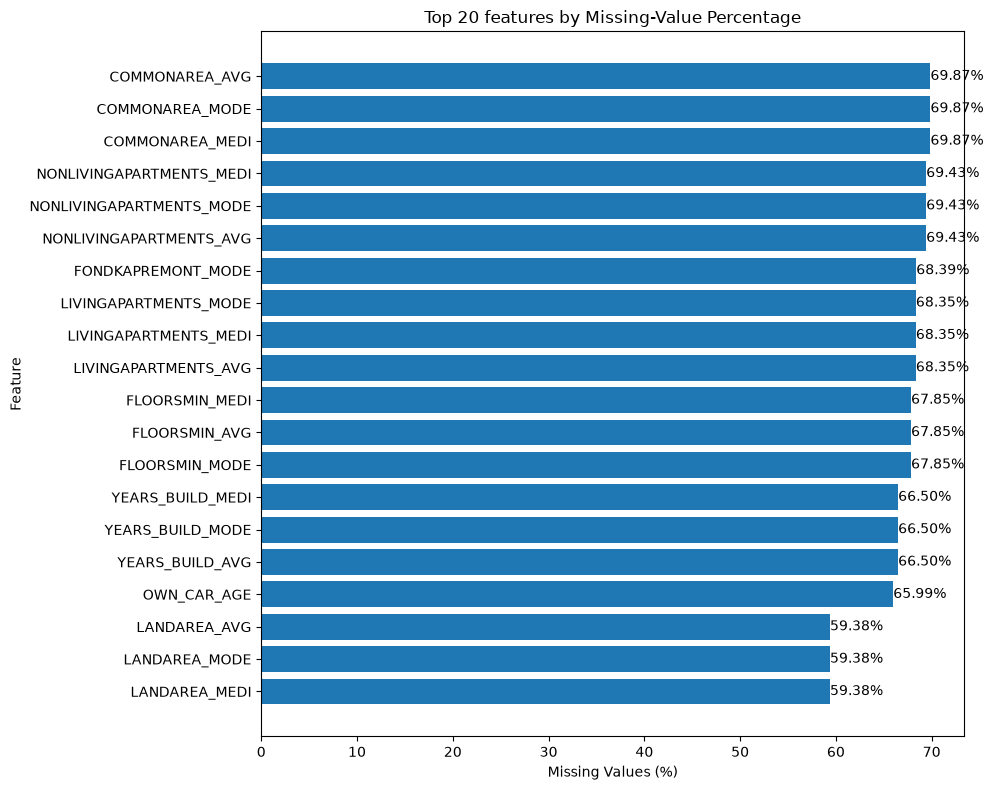

In [22]:
top_missing_for_plot = missing_summary.head(20).sort_values(by="Missing_Percentage", ascending=True)

fig,ax = plt.subplots(figsize=(10,8))
bars = ax.barh(top_missing_for_plot['Column'],
               top_missing_for_plot['Missing_Percentage'])
ax.set_title("Top 20 features by Missing-Value Percentage")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")

for bar, percentage in zip(bars, top_missing_for_plot['Missing_Percentage']):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{percentage:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Several property-related features contain very high missing-value percentages.

One possible explanation is that these features may apply only to customers who own or occupy certain types of property.

The missing values may therefore represent:

- Information not provided
- Information unavailable
- A feature not applicable to the customer

This should be confirmed using the column descriptions and business knowledge before making preprocessing decisions.

#### <b>Step 6: Categorize Features by Missing-Value Severity</b>

To make the analysis easier, we group features into missing-value ranges.

The ranges used are:

- No missing values
- More than 0% and up to 10%
- More than 10% and up to 30%
- More than 30% and up to 50%
- More than 50%

In [23]:
missing_percentage_all = (
    df.isnull().mean() * 100
)

missing_severity = {
    "No Missing Values": int(
        (missing_percentage_all == 0).sum()
    ),
    "0% to 10%": int(
        (
            (missing_percentage_all > 0)
            & (missing_percentage_all <= 10)
        ).sum()
    ),
    "10% to 30%": int(
        (
            (missing_percentage_all > 10)
            & (missing_percentage_all <= 30)
        ).sum()
    ),
    "30% to 50%": int(
        (
            (missing_percentage_all > 30)
            & (missing_percentage_all <= 50)
        ).sum()
    ),
    "Above 50%": int(
        (missing_percentage_all > 50).sum()
    ),
}

missing_severity_df = pd.DataFrame(
    {
        "Missing_Range": missing_severity.keys(),
        "Feature_Count": missing_severity.values(),
    }
)

print(missing_severity_df)

       Missing_Range  Feature_Count
0  No Missing Values             55
1          0% to 10%             10
2         10% to 30%              7
3         30% to 50%              9
4          Above 50%             41


##### <b>Business Interpretation</b>

The missing-value severity groups help us prioritize preprocessing work.

For example:

- Features with low missingness may be imputed using simple methods.
- Features with moderate missingness require more careful analysis.
- Features with very high missingness may be dropped, retained with missing indicators, or imputed using domain-specific rules.

No decision should be made only on the basis of a percentage threshold.

#### <b>Step 7: Check for Completely Empty Features</b>

A completely empty feature contains missing values for every record.

Such a feature provides no usable information and would normally be removed from the modeling dataset.

In [24]:
completely_empty_columns = (
    missing_percentage_all[
        missing_percentage_all == 100
    ]
    .index
    .tolist()
)

print(
    "Number of completely empty columns:",
    len(completely_empty_columns),
)

print(
    "Completely empty columns:",
    completely_empty_columns,
)

Number of completely empty columns: 0
Completely empty columns: []


##### <b>Observation</b>

If no columns are returned, the dataset does not contain any completely empty features.

This means every feature contains at least some available information.

However, features with very high missingness may still require additional review.

#### <b>Step 8: Analyze Missing Values by Feature Type</b>

Numerical and categorical features usually require different missing-value treatments.

Typical strategies include:

##### Numerical Features

- Median imputation
- Mean imputation
- Constant-value imputation
- Model-based imputation

##### Categorical Features

- Most-frequent category
- A separate `Unknown` category
- Business-specific category mapping

We first calculate how many numerical and categorical features contain missing values.

In [25]:
numerical_columns = df.select_dtypes(
    include="number"
).columns

categorical_columns = df.select_dtypes(
    include="object"
).columns

numerical_missing_columns = [
    column
    for column in numerical_columns
    if df[column].isnull().any()
]

categorical_missing_columns = [
    column
    for column in categorical_columns
    if df[column].isnull().any()
]

print(
    "Numerical columns with missing values:",
    len(numerical_missing_columns),
)

print(
    "Categorical columns with missing values:",
    len(categorical_missing_columns),
)

Numerical columns with missing values: 61
Categorical columns with missing values: 6


##### <b>Observation</b>

Both numerical and categorical features contain missing values.

Therefore, the preprocessing pipeline will require separate imputation strategies for each feature type.

A single universal imputation method would not be appropriate for the entire dataset.

#### <b>Step 9: Inspect Missing Values in Categorical Features</b>

For categorical variables, missing values may indicate:

- Unknown information
- Information not submitted
- A category that does not apply
- Data-entry problems

We list categorical features containing missing values and their percentages.

In [26]:
categorical_missing_summary = (
    missing_summary[
        missing_summary["Data_Type"] == "object"
    ]
    .reset_index(drop=True)
)

categorical_missing_summary

,Column,Missing_Count,Missing_Percentage,Data_Type
0,FONDKAPREMONT_MODE,210295,68.39,object
1,WALLSMATERIAL_MODE,156341,50.84,object
2,HOUSETYPE_MODE,154297,50.18,object
3,EMERGENCYSTATE_MODE,145755,47.40,object
4,OCCUPATION_TYPE,96391,31.35,object
5,NAME_TYPE_SUITE,1292,0.42,object


#### <b>Step 10: Inspect Missing Values in Numerical Features</b>

Numerical missing values may require imputation using methods such as the median or a model-based approach.

The median is often preferred over the mean when a feature contains outliers or has a skewed distribution.

In [27]:
numerical_missing_summary = (
    missing_summary[
        missing_summary["Data_Type"] != "object"
    ]
    .reset_index(drop=True)
)

numerical_missing_summary.head(20)

,Column,Missing_Count,Missing_Percentage,Data_Type
0,COMMONAREA_MEDI,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_AVG,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,LIVINGAPARTMENTS_AVG,210199,68.35,float64
7,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
8,LIVINGAPARTMENTS_MODE,210199,68.35,float64
9,FLOORSMIN_MEDI,208642,67.85,float64


#### <b>Step 11: Check Missingness in Selected Business Features</b>

Some features may be especially important for business interpretation and modeling.

We examine missing values in selected customer, income, credit, employment, and external-score features.

In [28]:
important_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "OCCUPATION_TYPE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_important_features = [
    column
    for column in important_features
    if column in df.columns
]

important_missing_summary = pd.DataFrame(
    {
        "Column": available_important_features,
        "Missing_Count": [
            int(df[column].isnull().sum())
            for column in available_important_features
        ],
        "Missing_Percentage": [
            round(
                df[column].isnull().mean() * 100,
                2,
            )
            for column in available_important_features
        ],
    }
)

print(important_missing_summary)

              Column  Missing_Count  Missing_Percentage
0             TARGET              0                0.00
1   AMT_INCOME_TOTAL              0                0.00
2         AMT_CREDIT              0                0.00
3        AMT_ANNUITY             12                0.00
4    AMT_GOODS_PRICE            278                0.09
5         DAYS_BIRTH              0                0.00
6      DAYS_EMPLOYED              0                0.00
7    OCCUPATION_TYPE          96391               31.35
8       EXT_SOURCE_1         173378               56.38
9       EXT_SOURCE_2            660                0.21
10      EXT_SOURCE_3          60965               19.83


##### <b>Business Insight</b>

Missingness in important features may have different meanings.

For example:

- Missing occupation information may indicate that employment details were not provided.
- Missing external credit scores may mean that the customer has limited credit-history information.
- Missing annuity or goods-price information may require investigation because these fields relate directly to loan terms.

The business meaning of a missing value should be considered before selecting an imputation strategy.

#### <b>Step 12: Compare Missingness Between Defaulters and Non-Defaulters</b>

Missing information may itself be related to default risk.

For example, customers with limited financial records may have different repayment behavior from customers with complete records.

We compare the average number of missing features per customer across the two target classes.

In [29]:
row_missing_count = df.isnull().sum(axis=1)

missing_by_target = (
    pd.DataFrame(
        {
            "TARGET": df["TARGET"],
            "Missing_Features_Per_Row": row_missing_count,
        }
    )
    .groupby("TARGET")[
        "Missing_Features_Per_Row"
    ]
    .agg(
        [
            "mean",
            "median",
            "min",
            "max",
        ]
    )
    .round(2)
)

print(missing_by_target)

        mean  median  min  max
TARGET                        
0       29.5    34.0    0   61
1       32.8    48.0    0   60


##### <b>Interpretation</b>

This comparison helps determine whether defaulters and non-defaulters differ in the amount of missing information.

If one class has a noticeably higher average number of missing features, missingness itself may contain predictive information.

This suggests that missing-value indicator features could be useful during feature engineering.

#### <b>Step 13: Create a Temporary Missing-Feature Count</b>

For exploratory analysis, we calculate how many features are missing for each customer.

This temporary variable is not added permanently to the original dataset at this stage.

In [30]:
missing_features_per_customer = (
    df.isnull().sum(axis=1)
)

missing_features_per_customer.describe()

count    307511.000000
mean         29.763049
std          20.919345
min           0.000000
25%           5.000000
50%          36.000000
75%          49.000000
max          61.000000
dtype: float64

##### <b>Observation</b>

The summary shows the distribution of incomplete features across customers.

Some customers may have very few missing fields, while others may have many.

During feature engineering, we may create a feature such as:

`TOTAL_MISSING_FEATURES`

This could help the model capture the overall completeness of a customer's application.

#### <b>Step 14: Preliminary Missing-Value Strategy</b>

Based on the analysis, the following strategies may be evaluated later:

##### Low Missing Percentage

- Numerical: median imputation
- Categorical: most-frequent category or `Unknown`

##### Moderate Missing Percentage

- Analyze business relevance
- Add a missing-value indicator
- Apply robust imputation
- Compare model performance with and without the feature

##### High Missing Percentage

- Investigate the business meaning
- Consider dropping the feature
- Retain it if missingness is informative
- Add an explicit missing indicator
- Compare through cross-validation

These are preliminary decisions only. Final handling will be implemented in the preprocessing pipeline.

#### <b>Important: Avoid Data Leakage During Imputation</b>

Imputation values must be learned only from the training dataset.

For example, the median of a numerical feature should be calculated from the training data and then applied to both:

- Training data
- Validation or test data

Calculating imputation values from the complete dataset would expose information from the test data to the training process and create data leakage.

We will prevent this by using a Scikit-learn pipeline during the transformation stage.

#### <b>Business Insights</b>

1. Missing values are distributed across many features rather than being limited to one or two columns.
2. Several property-related features contain high missing percentages.
3. Missingness may represent unavailable, unreported, or non-applicable information.
4. Features with high missingness should not be dropped automatically.
5. Numerical and categorical features require different treatment strategies.
6. Missing information may itself be related to default risk.
7. Missing-value handling must be learned from the training data only to prevent data leakage.

#### <b>Session 3 Summary</b>

In this session, we:

- Calculated the total number of missing values
- Counted features containing missing values
- Created a missing-value summary table
- Identified features with the highest missing percentages
- Grouped features by missing-value severity
- Checked for completely empty features
- Analyzed missing values by data type
- Reviewed missingness in important business features
- Compared missingness across target classes
- Discussed preliminary imputation strategies
- Identified a possible missing-count feature
- Reviewed how to prevent data leakage during imputation

No missing values were removed or imputed during this session.

The next session will focus on numerical-feature analysis.

### <b>Session 4: Numerical Feature Analysis</b>

**Objective**

The objective of this session is to analyze the numerical features in the loan application dataset.

Numerical analysis helps us understand:

- Feature ranges
- Central tendency
- Variability
- Skewed distributions
- Extreme values
- Possible data-quality problems
- Relationships with loan-default risk

The findings from this session will guide later decisions related to scaling, transformation, outlier handling, and feature engineering.

#### <b>Business Context</b>

Loan-default risk can be influenced by several numerical characteristics, such as:

- Customer income
- Requested loan amount
- Loan annuity
- Age
- Employment duration
- Family size
- External credit scores

Understanding these features helps the business identify patterns associated with reliable and risky customers.

However, numerical features may also contain:

- Extreme values
- Invalid values
- Highly skewed distributions
- Missing observations
- Different measurement scales

These issues must be understood before model training.

#### <b>Step 1: Identify Numerical Features</b>

We begin by identifying all columns stored as numerical data types.

The dataset contains both:

- Continuous numerical features, such as income and credit amount
- Discrete numerical features, such as number of children and number of family members

The target and identification columns may also appear as numerical, but they should not be treated as regular model features during analysis.

In [31]:
numerical_columns = df.select_dtypes(
    include="number"
).columns.tolist()

print("Total numerical columns:", len(numerical_columns))
print(numerical_columns)

Total numerical columns: 106
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_B

##### <b>Observation</b>

The dataset contains a large number of numerical features.

Not all numerical columns represent continuous measurements.

For example:

- `SK_ID_CURR` is an identifier.
- `TARGET` is the target label.
- Some flag columns contain only `0` and `1`.
- Some count columns contain small integer values.

Therefore, data type alone is not enough to determine how a feature should be analyzed or transformed.

#### <b>Step 2: Select Important Numerical Features for Detailed Analysis</b>

Because the dataset contains many numerical columns, analyzing every feature individually would make the notebook difficult to interpret.

We will first focus on important business-related numerical features:

- `AMT_INCOME_TOTAL`
- `AMT_CREDIT`
- `AMT_ANNUITY`
- `AMT_GOODS_PRICE`
- `DAYS_BIRTH`
- `DAYS_EMPLOYED`
- `CNT_CHILDREN`
- `CNT_FAM_MEMBERS`
- `EXT_SOURCE_1`
- `EXT_SOURCE_2`
- `EXT_SOURCE_3`

These features represent customer demographics, loan information, and external credit-risk indicators.

In [32]:
important_numerical_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_numerical_features = [
    column
    for column in important_numerical_features
    if column in df.columns
]

print(available_numerical_features)

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


#### <b>Step 3: Generate a Statistical Summary</b>

The `describe()` function provides a statistical summary of numerical features.

It includes:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This helps us identify unusual ranges, possible outliers, missing values, and skewed distributions.

In [33]:
numerical_summary = (
    df[available_numerical_features]
    .describe()
    .T
)

print(numerical_summary)

                     count           mean            std           min  \
AMT_INCOME_TOTAL  307511.0  168797.919297  237123.146279  2.565000e+04   
AMT_CREDIT        307511.0  599025.999706  402490.776996  4.500000e+04   
AMT_ANNUITY       307499.0   27108.573909   14493.737315  1.615500e+03   
AMT_GOODS_PRICE   307233.0  538396.207429  369446.460540  4.050000e+04   
DAYS_BIRTH        307511.0  -16036.995067    4363.988632 -2.522900e+04   
DAYS_EMPLOYED     307511.0   63815.045904  141275.766519 -1.791200e+04   
CNT_CHILDREN      307511.0       0.417052       0.722121  0.000000e+00   
CNT_FAM_MEMBERS   307509.0       2.152665       0.910682  1.000000e+00   
EXT_SOURCE_1      134133.0       0.502130       0.211062  1.456813e-02   
EXT_SOURCE_2      306851.0       0.514393       0.191060  8.173617e-08   
EXT_SOURCE_3      246546.0       0.510853       0.194844  5.272652e-04   

                            25%            50%            75%           max  
AMT_INCOME_TOTAL  112500.000000  

##### <b>Observation</b>

The statistical summary shows that the numerical features have very different scales.

For example:

- Income and credit amounts may contain very large values.
- External-source scores usually lie within a smaller range.
- Age and employment duration are recorded as negative numbers of days.
- Some features contain missing observations, as indicated by reduced counts.

This means that different preprocessing strategies may be required for different numerical features.

#### <b>Step 4: Create an Extended Numerical Summary</b>

To improve the analysis, we add:

- Missing-value percentage
- Number of unique values
- Skewness

Skewness measures the asymmetry of a distribution.

General interpretation:

- Skewness close to `0`: approximately symmetric
- Positive skewness: long right tail
- Negative skewness: long left tail

In [34]:
extended_numerical_summary = pd.DataFrame(
    index=available_numerical_features
)

extended_numerical_summary["Data_Type"] = (
    df[available_numerical_features]
    .dtypes
    .astype(str)
)

extended_numerical_summary["Missing_Percentage"] = (
    df[available_numerical_features]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

extended_numerical_summary["Unique_Values"] = (
    df[available_numerical_features]
    .nunique()
)

extended_numerical_summary["Mean"] = (
    df[available_numerical_features]
    .mean()
    .round(2)
)

extended_numerical_summary["Median"] = (
    df[available_numerical_features]
    .median()
    .round(2)
)

extended_numerical_summary["Skewness"] = (
    df[available_numerical_features]
    .skew()
    .round(2)
)

print(extended_numerical_summary)

                 Data_Type  Missing_Percentage  Unique_Values       Mean  \
AMT_INCOME_TOTAL   float64                0.00           2548  168797.92   
AMT_CREDIT         float64                0.00           5603  599026.00   
AMT_ANNUITY        float64                0.00          13672   27108.57   
AMT_GOODS_PRICE    float64                0.09           1002  538396.21   
DAYS_BIRTH           int64                0.00          17460  -16037.00   
DAYS_EMPLOYED        int64                0.00          12574   63815.05   
CNT_CHILDREN         int64                0.00             15       0.42   
CNT_FAM_MEMBERS    float64                0.00             17       2.15   
EXT_SOURCE_1       float64               56.38         114584       0.50   
EXT_SOURCE_2       float64                0.21         119831       0.51   
EXT_SOURCE_3       float64               19.83            814       0.51   

                     Median  Skewness  
AMT_INCOME_TOTAL  147150.00    391.56  
AMT_CRE

##### <b>Interpretation</b>

A large difference between the mean and median may indicate skewness or extreme values.

For example:

- If the mean is much greater than the median, the distribution may be right-skewed.
- If the mean is much smaller than the median, the distribution may be left-skewed.

Highly skewed features may later require:

- Log transformation
- Robust scaling
- Outlier capping
- Tree-based models that are less sensitive to feature scale

#### <b>Step 5: Analyze Customer Income</b>

`AMT_INCOME_TOTAL` represents the customer's total income.

Income may influence loan repayment capacity, but income alone cannot determine whether a customer will default.

We analyze:

- Distribution
- Central tendency
- Skewness
- Extreme values

In [35]:
income_summary = df["AMT_INCOME_TOTAL"].describe()

print(income_summary)

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


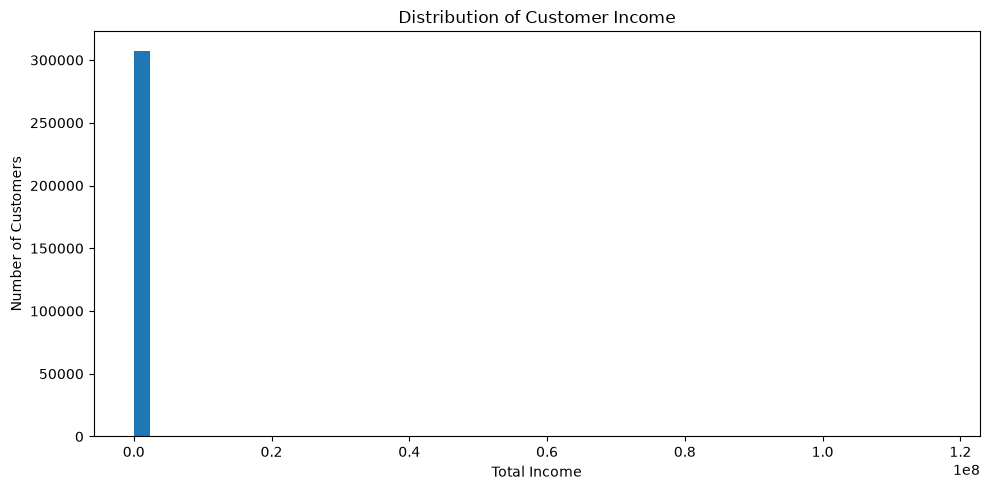

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["AMT_INCOME_TOTAL"].dropna(),
    bins=50,
)

ax.set_title("Distribution of Customer Income")
ax.set_xlabel("Total Income")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

The income distribution is expected to be strongly right-skewed.

Most customers fall within lower or moderate income ranges, while a small number of customers have extremely high incomes.

These extreme values stretch the horizontal scale and make the main distribution difficult to inspect.

#### <b>Step 6: Visualize the Main Income Distribution</b>

Because extreme values can compress the main part of the histogram, we inspect income values below the 99th percentile.

This is only for visualization.

No records are removed from the dataset.

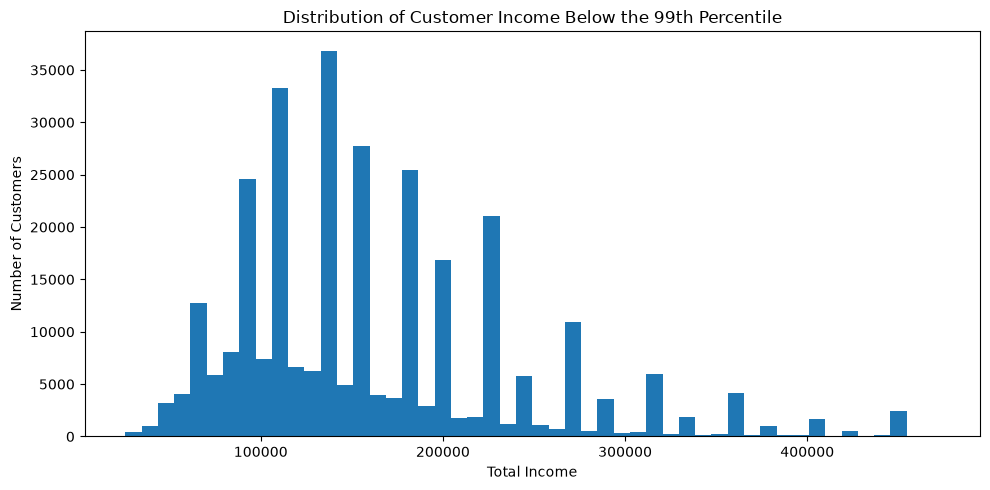

In [37]:
income_99th_percentile = df[
    "AMT_INCOME_TOTAL"
].quantile(0.99)

income_for_visualization = df.loc[
    df["AMT_INCOME_TOTAL"]
    <= income_99th_percentile,
    "AMT_INCOME_TOTAL",
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    income_for_visualization.dropna(),
    bins=50,
)

ax.set_title(
    "Distribution of Customer Income Below the 99th Percentile"
)
ax.set_xlabel("Total Income")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

Most applicants are concentrated within a limited income range.

A small number of very high-income applicants create a long right tail.

For modeling, we may later consider:

- Log transformation
- Robust scaling
- Outlier capping
- Income-related ratio features

However, high-income values should not be removed automatically because they may represent genuine customers.

#### <b>Step 7: Analyze Loan Credit Amount</b>

`AMT_CREDIT` represents the total loan amount requested or granted.

Credit amount is an important business feature because larger loans may create greater financial exposure.

However, default risk depends not only on the loan amount, but also on the customer's income, repayment capacity, and loan terms.

In [38]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

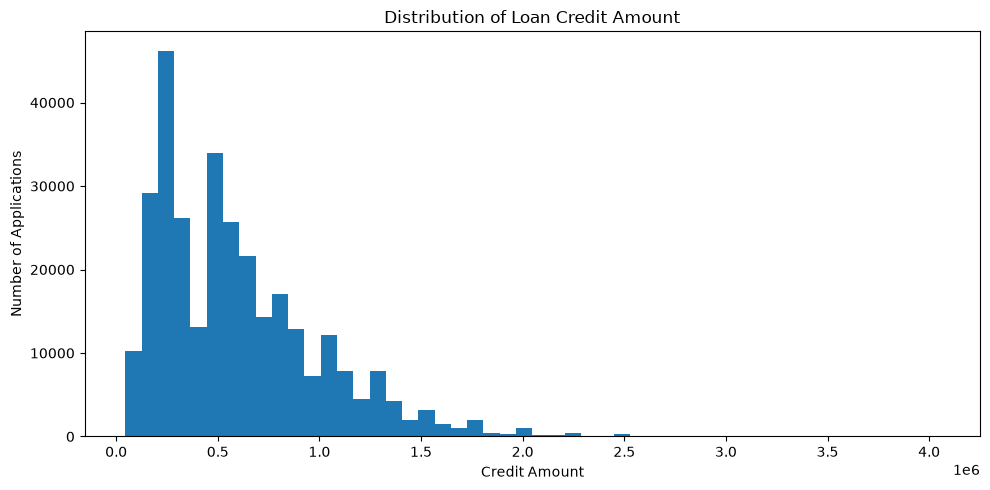

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["AMT_CREDIT"].dropna(),
    bins=50,
)

ax.set_title("Distribution of Loan Credit Amount")
ax.set_xlabel("Credit Amount")
ax.set_ylabel("Number of Applications")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

The credit-amount distribution may show several peaks rather than a perfectly smooth pattern.

This can happen because loan amounts are often offered in standard packages or rounded values.

The distribution may also be right-skewed, with fewer applications involving very large loan amounts.

#### <b>Step 8: Analyze Loan Annuity</b>

`AMT_ANNUITY` represents the periodic repayment amount.

A higher annuity may place greater pressure on a customer's monthly budget.

However, its effect should be analyzed relative to income rather than independently.

In [40]:
df["AMT_ANNUITY"].describe()

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

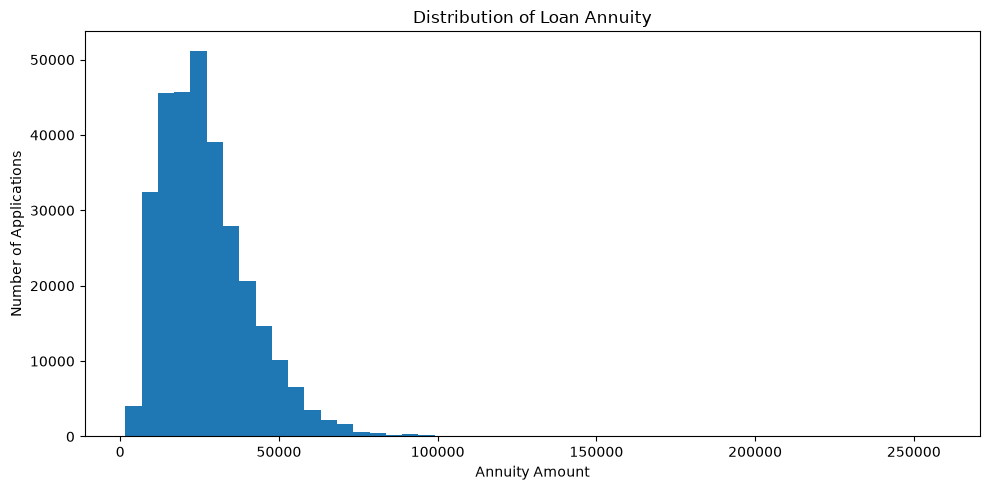

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["AMT_ANNUITY"].dropna(),
    bins=50,
)

ax.set_title("Distribution of Loan Annuity")
ax.set_xlabel("Annuity Amount")
ax.set_ylabel("Number of Applications")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

The annuity amount alone may not clearly indicate default risk.

A more useful feature may be the ratio between annuity and income:

`ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL`

A high ratio may indicate that a large portion of the customer's income is required for loan repayment.

#### <b>Step 9: Analyze Goods Price</b>

`AMT_GOODS_PRICE` represents the price of the goods for which the loan was provided.

This feature is usually related to the credit amount.

A large difference between goods price and credit amount may reveal financing structure, down-payment behavior, or additional costs.

In [42]:
df["AMT_GOODS_PRICE"].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

In [43]:
credit_goods_summary = df[
    [
        "AMT_CREDIT",
        "AMT_GOODS_PRICE",
    ]
].describe().T

credit_goods_summary

,count,mean,std,min,25%,50%,75%,max
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


##### <b>Feature Engineering Idea</b>

We may later create:

`CREDIT_GOODS_RATIO = AMT_CREDIT / AMT_GOODS_PRICE`

This ratio may help identify whether the loan amount is high relative to the underlying goods price.

#### <b>Step 10: Analyze Customer Age</b>

`DAYS_BIRTH` stores customer age as a negative number of days relative to the loan application date.

For easier interpretation, we temporarily convert it to years:

`AGE_YEARS = -DAYS_BIRTH / 365.25`

This conversion is used only for analysis at this stage.

In [44]:
age_years = (
    -df["DAYS_BIRTH"] / 365.25
)

age_years.describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: DAYS_BIRTH, dtype: float64

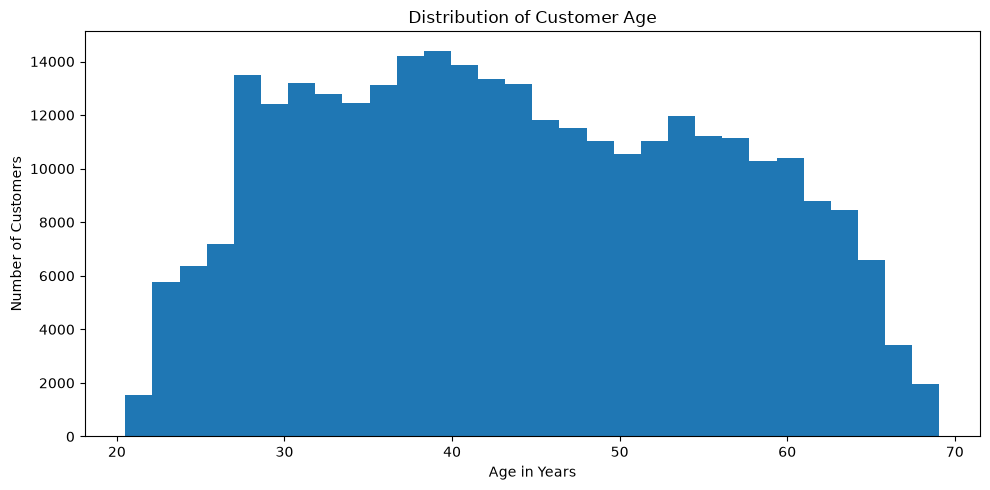

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    age_years.dropna(),
    bins=30,
)

ax.set_title("Distribution of Customer Age")
ax.set_xlabel("Age in Years")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

The applicant population covers a broad range of ages.

Age may be associated with:

- Employment stability
- Credit history length
- Income stability
- Family responsibilities
- Retirement status

Age should be interpreted carefully because it may also introduce fairness and regulatory concerns in lending decisions.

#### <b>Step 11: Compare Customer Age by Default Status</b>

We compare the average and median age of:

- Non-default customers
- Default customers

This helps identify whether age patterns differ between the two groups.

In [46]:
age_target_analysis = pd.DataFrame(
    {
        "TARGET": df["TARGET"],
        "AGE_YEARS": age_years,
    }
)

age_by_target = (
    age_target_analysis
    .groupby("TARGET")["AGE_YEARS"]
    .agg(
        [
            "mean",
            "median",
            "min",
            "max",
        ]
    )
    .round(2)
)

print(age_by_target)

         mean  median    min    max
TARGET                             
0       44.18   43.47  20.50  69.07
1       40.75   39.10  21.02  68.91


##### <b>Interpretation</b>

If the average age of defaulters differs from that of non-defaulters, age may contain predictive information.

However, a difference in averages does not prove causation.

Further analysis and model validation are required before drawing conclusions.

#### <b>Step 12: Analyze Employment Duration</b>

`DAYS_EMPLOYED` represents the number of days the customer has been employed.

The values are recorded as negative numbers.

A longer employment history may indicate greater income stability.

However, this feature contains a known unusual value that requires investigation.

In [47]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

#### <b>Step 13: Investigate Unusual Employment Values</b>

Some records in `DAYS_EMPLOYED` contain the value `365243`.

This value does not represent a realistic employment duration.

It is commonly treated as a special placeholder indicating unavailable or non-applicable employment information.

In [48]:
special_employment_value = 365243

special_employment_count = int(
    (
        df["DAYS_EMPLOYED"]
        == special_employment_value
    ).sum()
)

special_employment_percentage = (
    special_employment_count / len(df)
) * 100

print(
    "Special employment value count:",
    f"{special_employment_count:,}",
)

print(
    "Special employment value percentage:",
    f"{special_employment_percentage:.2f}%",
)

Special employment value count: 55,374
Special employment value percentage: 18.01%


##### <b>Observation</b>

The value `365243` is not a realistic employment duration.

It should not be treated as a normal numerical value because it would distort:

- Mean
- Standard deviation
- Distribution
- Scaling
- Model relationships

During preprocessing, this value may be replaced with a missing value and handled separately.

#### <b>Step 14: Analyze Employment Duration After Excluding the Special Value</b>

For exploratory visualization, we exclude the special placeholder value and convert valid employment duration into years.

This does not permanently modify the dataset.

In [49]:
valid_employment_days = df.loc[
    df["DAYS_EMPLOYED"] != special_employment_value,
    "DAYS_EMPLOYED",
]

employment_years = (
    -valid_employment_days / 365.25
)

employment_years.describe()

count    252137.000000
mean          6.527500
std           6.402081
min           0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: DAYS_EMPLOYED, dtype: float64

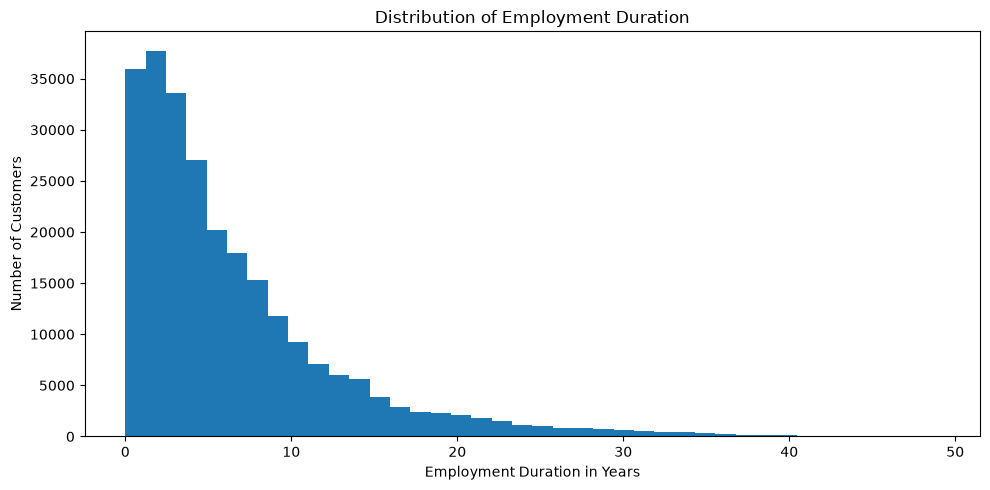

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    employment_years.dropna(),
    bins=40,
)

ax.set_title("Distribution of Employment Duration")
ax.set_xlabel("Employment Duration in Years")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

Employment duration may indicate job stability and repayment capacity.

Customers with very short employment histories may have less stable income.

However, employment duration should be interpreted together with:

- Age
- Occupation
- Income
- Employment type
- Organization type

#### <b>Step 15: Analyze Number of Children</b>

`CNT_CHILDREN` represents the number of children in the customer's family.

This variable may influence household expenses and repayment capacity.

Because this is a discrete count variable, its distribution should be analyzed differently from continuous financial features.

In [51]:
children_counts = (
    df["CNT_CHILDREN"]
    .value_counts()
    .sort_index()
)

children_counts.head(15)

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

[2026-07-23 18:12:24,080] INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-07-23 18:12:24,084] INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


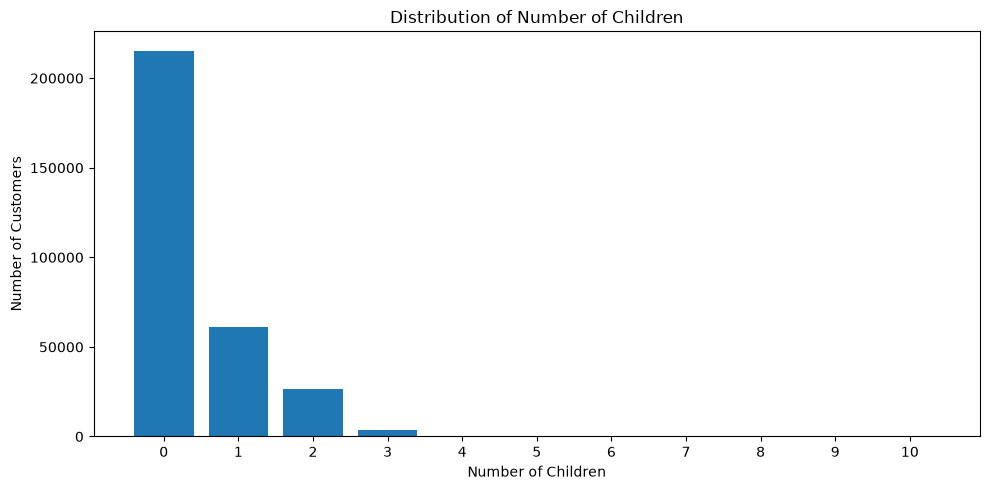

In [52]:
children_plot_data = children_counts[
    children_counts.index <= 10
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    children_plot_data.index.astype(str),
    children_plot_data.values,
)

ax.set_title("Distribution of Number of Children")
ax.set_xlabel("Number of Children")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Most customers are expected to have zero or a small number of children.

Very large values may be rare and should be reviewed as possible outliers or genuine large-family records.

The number of children should not be treated exactly like a continuous financial feature.

#### <b>Step 16: Analyze Family Size</b>

`CNT_FAM_MEMBERS` represents the number of people in the customer's family.

Family size may affect household expenses and disposable income.

Missing values and unusual family sizes should be reviewed before modeling.

In [53]:
df["CNT_FAM_MEMBERS"].describe()

count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

In [54]:
family_member_counts = (
    df["CNT_FAM_MEMBERS"]
    .value_counts()
    .sort_index()
)

family_member_counts.head(15)

CNT_FAM_MEMBERS
1.0      67847
2.0     158357
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
11.0         1
12.0         2
13.0         1
14.0         2
15.0         1
Name: count, dtype: int64

#### <b>Step 17: Analyze External Credit Scores</b>

The features:

- `EXT_SOURCE_1`
- `EXT_SOURCE_2`
- `EXT_SOURCE_3`

represent external risk-score information.

These features may be strong predictors of default risk.

Higher or lower score interpretations should be confirmed from the data and official feature descriptions rather than assumed without analysis.

In [55]:
external_source_columns = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

df[external_source_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010


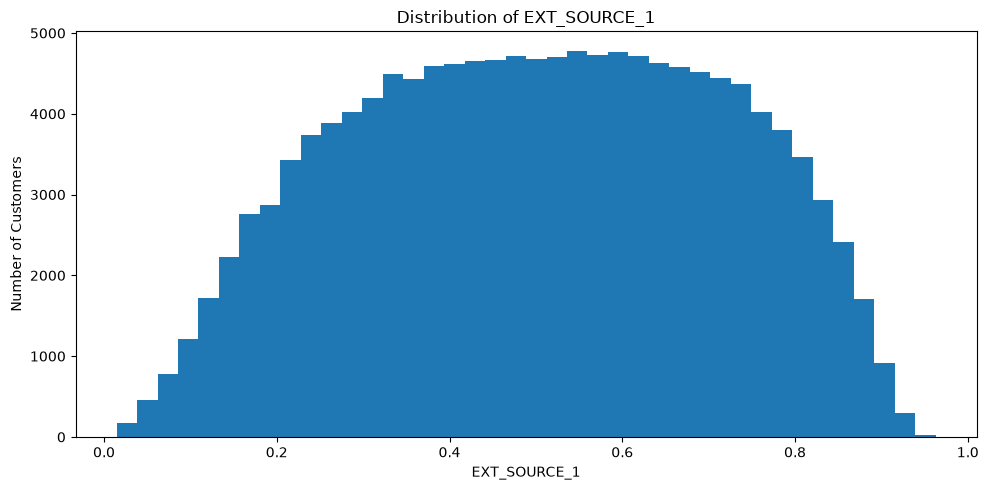

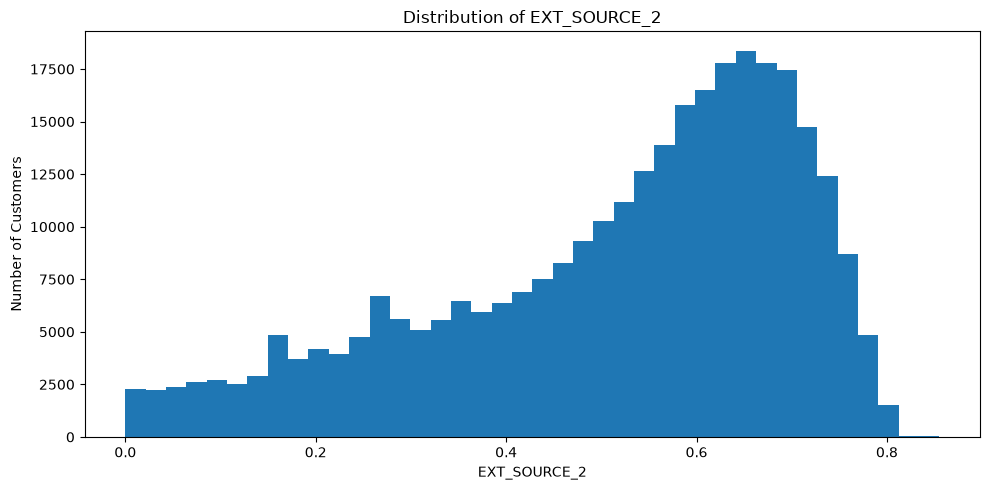

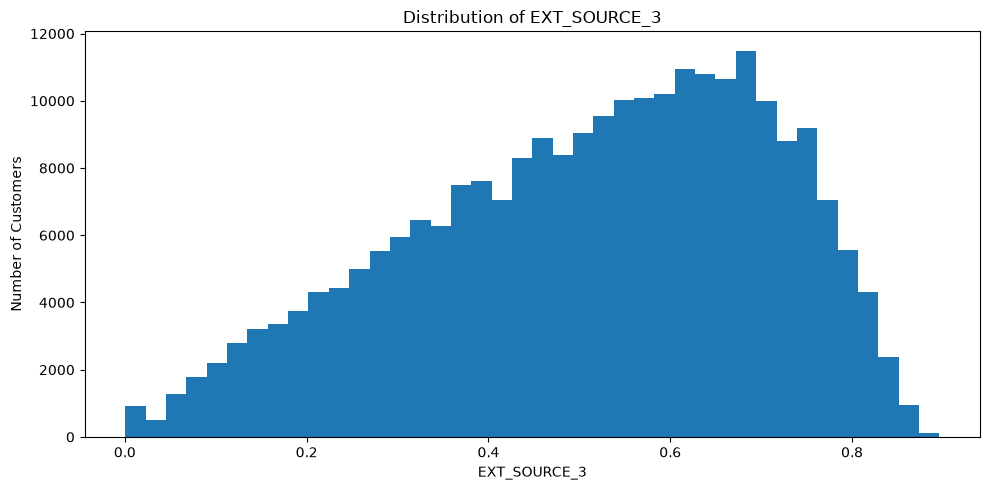

In [56]:
for column in external_source_columns:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(
        df[column].dropna(),
        bins=40,
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

##### <b>Observation</b>

The external-source features have different missing-value rates and distributions.

They should not automatically be combined or imputed using the same rule.

Their relationship with the target variable should be examined before deciding how to use them.

#### <b>Step 18: Compare Numerical Features Across Target Classes</b>

We compare the mean and median values of important numerical features for:

- Class `0`: No default
- Class `1`: Default

This helps identify features whose distributions may differ between defaulters and non-defaulters.

In [57]:
target_comparison_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_target_comparison_features = [
    column
    for column in target_comparison_features
    if column in df.columns
]

mean_by_target = (
    df.groupby("TARGET")[
        available_target_comparison_features
    ]
    .mean()
    .T
    .round(2)
)

mean_by_target.columns = [
    "No_Default_Mean",
    "Default_Mean",
]

print(mean_by_target)

                  No_Default_Mean  Default_Mean
AMT_INCOME_TOTAL        169077.72     165611.76
AMT_CREDIT              602648.28     557778.53
AMT_ANNUITY              27163.62      26481.74
AMT_GOODS_PRICE         542736.80     488972.41
CNT_CHILDREN                 0.41          0.46
CNT_FAM_MEMBERS              2.15          2.18
EXT_SOURCE_1                 0.51          0.39
EXT_SOURCE_2                 0.52          0.41
EXT_SOURCE_3                 0.52          0.39


In [58]:
median_by_target = (
    df.groupby("TARGET")[
        available_target_comparison_features
    ]
    .median()
    .T
    .round(2)
)

median_by_target.columns = [
    "No_Default_Median",
    "Default_Median",
]

print(median_by_target)

                  No_Default_Median  Default_Median
AMT_INCOME_TOTAL          148500.00       135000.00
AMT_CREDIT                517788.00       497520.00
AMT_ANNUITY                24876.00        25263.00
AMT_GOODS_PRICE           450000.00       450000.00
CNT_CHILDREN                   0.00            0.00
CNT_FAM_MEMBERS                2.00            2.00
EXT_SOURCE_1                   0.52            0.36
EXT_SOURCE_2                   0.57            0.44
EXT_SOURCE_3                   0.55            0.38


##### <b>Interpretation</b>

Differences between class-level means and medians may suggest that certain features are associated with default risk.

However:

- Averages can be affected by outliers.
- Association does not imply causation.
- A difference does not guarantee strong predictive power.
- Statistical and model-based validation will still be required.

#### <b>Step 19: Compare Selected Numerical Features Using Box Plots</b>

Box plots help compare the distribution of a numerical feature across target classes.

They display:

- Median
- Lower quartile
- Upper quartile
- Interquartile range
- Potential outliers

Because some financial variables contain extreme values, we use percentile-based limits for visualization only.

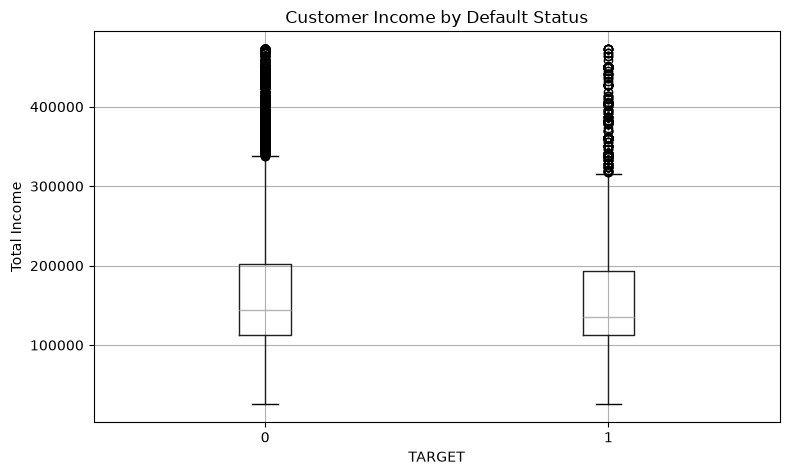

In [59]:
income_upper_limit = df[
    "AMT_INCOME_TOTAL"
].quantile(0.99)

income_box_data = df.loc[
    df["AMT_INCOME_TOTAL"]
    <= income_upper_limit,
    [
        "TARGET",
        "AMT_INCOME_TOTAL",
    ],
]

fig, ax = plt.subplots(figsize=(8, 5))

income_box_data.boxplot(
    column="AMT_INCOME_TOTAL",
    by="TARGET",
    ax=ax,
)

ax.set_title("Customer Income by Default Status")
ax.set_xlabel("TARGET")
ax.set_ylabel("Total Income")

plt.suptitle("")
plt.tight_layout()
plt.show()

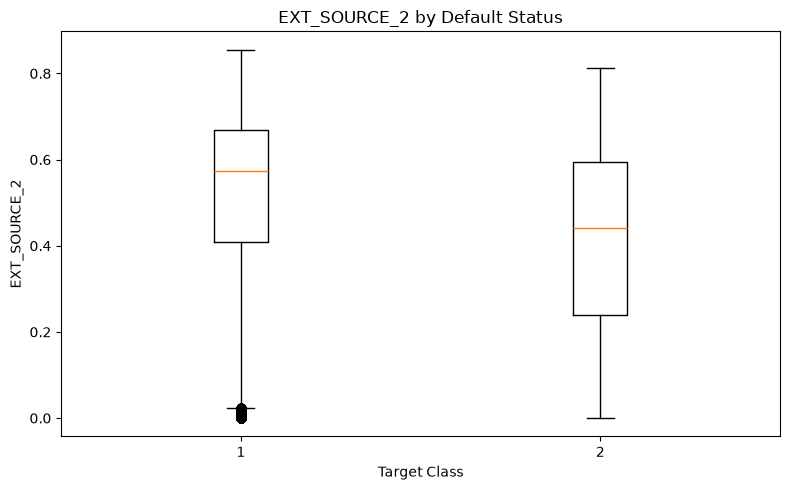

In [60]:
external_score_data = [
    df.loc[
        df["TARGET"] == target_value,
        "EXT_SOURCE_2",
    ].dropna()
    for target_value in [0, 1]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    external_score_data,
    label=[
        "No Default",
        "Default",
    ],
)

ax.set_title("EXT_SOURCE_2 by Default Status")
ax.set_xlabel("Target Class")
ax.set_ylabel("EXT_SOURCE_2")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Box plots may reveal differences in median values and distribution ranges between defaulters and non-defaulters.

Features with visible separation between the two classes may contain useful predictive information.

However, overlapping distributions are expected because no single feature is likely to perfectly separate default and non-default customers.

#### <b>Step 20: Identify Highly Skewed Numerical Features</b>

Highly skewed features may affect:

- Linear models
- Distance-based models
- Scaling
- Statistical interpretation

We identify numerical features whose absolute skewness is greater than `1`.

In [61]:
model_numerical_columns = [
    column
    for column in numerical_columns
    if column not in [
        "TARGET",
        "SK_ID_CURR",
    ]
]

numerical_skewness = (
    df[model_numerical_columns]
    .skew()
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
)

highly_skewed_features = numerical_skewness[
    numerical_skewness.abs() > 1
]

print(
    "Number of highly skewed numerical features:",
    len(highly_skewed_features),
)

highly_skewed_features.head(20)

Number of highly skewed numerical features: 86


FLAG_MOBIL                  -554.536744
FLAG_DOCUMENT_12             392.114779
AMT_INCOME_TOTAL             391.559654
FLAG_DOCUMENT_10             209.589054
FLAG_DOCUMENT_2              153.791817
AMT_REQ_CREDIT_BUREAU_QRT    134.365776
FLAG_DOCUMENT_4              110.894364
FLAG_DOCUMENT_7               72.174108
FLAG_DOCUMENT_17              61.214140
FLAG_DOCUMENT_21              54.612939
FLAG_DOCUMENT_20              44.364897
FLAG_DOCUMENT_19              40.956134
FLAG_DOCUMENT_15              28.699333
AMT_REQ_CREDIT_BUREAU_DAY     27.043505
FLAG_CONT_MOBILE             -23.081172
FLAG_DOCUMENT_14              18.372533
FLAG_DOCUMENT_13              16.753746
NONLIVINGAPARTMENTS_MODE      16.251819
FLAG_DOCUMENT_9               15.927755
FLAG_DOCUMENT_11              15.894229
dtype: float64

##### <b>Interpretation</b>

Highly skewed features may later require transformations such as:

- `log1p`
- Square-root transformation
- Quantile transformation
- Robust scaling
- Capping extreme values

The final decision should depend on the selected algorithm.

Tree-based models are generally less sensitive to skewness than linear or distance-based models.

#### <b>Step 21: Check for Infinite Numerical Values</b>

Infinite values can cause preprocessing and model-training failures.

They may appear after incorrect mathematical calculations or divisions.

We check whether the original numerical features contain positive or negative infinity.

In [62]:
infinite_value_count = int(
    np.isinf(
        df[numerical_columns]
        .select_dtypes(include="number")
    )
    .sum()
    .sum()
)

print(
    "Total infinite values:",
    infinite_value_count,
)

Total infinite values: 0


#### <b>Step 22: Preliminary Numerical Preprocessing Decisions</b>

Based on the numerical analysis, the following strategies may be evaluated later:

##### Missing Values

- Median imputation for skewed numerical features
- Missing indicators where missingness may be informative

##### Extreme Values

- Validate using business rules
- Use percentile capping where justified
- Avoid automatic deletion

##### Skewed Features

- Log transformation
- Robust scaling
- Tree-based models

##### Date-Based Features

- Convert negative day values into interpretable years
- Replace special placeholder values such as `365243`

##### Ratio Features

Potential engineered features include:

- Credit-to-income ratio
- Annuity-to-income ratio
- Credit-to-goods-price ratio
- Employment-to-age ratio
- Income per family member

##### <b>Important Reminder: Outliers Are Not Always Errors</b>

An extreme numerical value may represent:

- A wealthy customer
- A large loan application
- A large family
- A data-entry problem
- A special placeholder value

Therefore, outliers should not be removed automatically.

Each unusual value should be investigated using:

- Business meaning
- Feature documentation
- Distribution analysis
- Model performance

#### <b>Business Insights</b>

1. Income, credit, annuity, and goods-price features are generally right-skewed.
2. Financial features contain extreme values that may represent genuine customers.
3. Credit and annuity should be analyzed relative to income rather than independently.
4. Age and employment duration are stored as day-based values and require conversion for interpretation.
5. `DAYS_EMPLOYED` contains a special value that should not be treated as a normal duration.
6. Family-size features are discrete counts rather than continuous measurements.
7. External credit-source features may have strong relationships with default risk.
8. No single numerical feature is expected to perfectly distinguish defaulters from non-defaulters.
9. Ratio-based features may provide better business information than raw values alone.

#### <b>Session 4 Summary</b>

In this session, we:

- Identified numerical features
- Generated statistical summaries
- Measured skewness
- Analyzed income, credit, annuity, and goods price
- Converted age into years for interpretation
- Investigated employment duration
- Detected the special `DAYS_EMPLOYED` value
- Analyzed children and family size
- Studied external credit scores
- Compared numerical features across target classes
- Used box plots to compare distributions
- Identified highly skewed features
- Checked for infinite values
- Defined preliminary preprocessing and feature-engineering strategies

No numerical feature was permanently modified or removed during this session.

The next session will focus on categorical-feature analysis.

### <b>Session 5: Categorical Feature Analysis</b>

**Objective**

The objective of this session is to analyze categorical features in the loan-default dataset.

Categorical analysis helps us understand:

- The number of categories in each feature
- The frequency of each category
- Missing and rare categories
- Whether some categories show higher default rates
- Which columns may require special encoding
- Which features may contain redundant or unhelpful information

The insights from this session will guide later decisions related to missing-value handling, category grouping, feature encoding, and feature selection.

#### <b>Business Context</b>

Categorical variables describe customer and loan characteristics such as:

- Gender
- Income type
- Education level
- Family status
- Housing type
- Occupation
- Organization type
- Loan contract type

These features may contain useful patterns related to repayment behavior.

For example:

- Some income types may provide more stable income than others.
- Housing status may reflect financial stability.
- Occupation and organization type may be related to employment risk.
- Education level may be associated with income and credit history.

However, these relationships must be studied carefully because association does not necessarily imply causation.

#### <b>Step 1: Identify Categorical Features</b>

We begin by selecting columns stored as categorical or object data types.

These columns usually contain text labels rather than continuous numerical measurements.

In [63]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Total categorical columns:", len(categorical_columns))
print(categorical_columns)

Total categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


##### <b>Observation</b>

The dataset contains multiple categorical features representing customer demographics, employment information, housing details, and loan characteristics.

Some categorical features may contain only a few categories, while others may contain many unique values.

The number of categories will influence the encoding strategy used later.

#### <b>Step 2: Create a Categorical Feature Summary</b>

For each categorical feature, we calculate:

- Number of unique categories
- Number of missing values
- Missing-value percentage
- Most frequent category
- Frequency of the most common category

This provides a high-level overview of the categorical data.

In [64]:
categorical_summary_records = []

for column in categorical_columns:
    value_counts = df[column].value_counts(
        dropna=True
    )

    most_frequent_category = (
        value_counts.index[0]
        if not value_counts.empty
        else None
    )

    most_frequent_count = (
        int(value_counts.iloc[0])
        if not value_counts.empty
        else 0
    )

    categorical_summary_records.append(
        {
            "Column": column,
            "Unique_Categories": int(
                df[column].nunique(dropna=True)
            ),
            "Missing_Count": int(
                df[column].isnull().sum()
            ),
            "Missing_Percentage": round(
                df[column].isnull().mean() * 100,
                2,
            ),
            "Most_Frequent_Category": (
                most_frequent_category
            ),
            "Most_Frequent_Count": (
                most_frequent_count
            ),
            "Most_Frequent_Percentage": round(
                most_frequent_count / len(df) * 100,
                2,
            ),
        }
    )

categorical_summary = pd.DataFrame(
    categorical_summary_records
).sort_values(
    by="Unique_Categories",
    ascending=False,
).reset_index(drop=True)

print(categorical_summary)

                        Column  Unique_Categories  Missing_Count  \
0            ORGANIZATION_TYPE                 58              0   
1              OCCUPATION_TYPE                 18          96391   
2             NAME_INCOME_TYPE                  8              0   
3              NAME_TYPE_SUITE                  7           1292   
4           WALLSMATERIAL_MODE                  7         156341   
5   WEEKDAY_APPR_PROCESS_START                  7              0   
6           NAME_FAMILY_STATUS                  6              0   
7            NAME_HOUSING_TYPE                  6              0   
8          NAME_EDUCATION_TYPE                  5              0   
9           FONDKAPREMONT_MODE                  4         210295   
10              HOUSETYPE_MODE                  3         154297   
11                 CODE_GENDER                  3              0   
12                FLAG_OWN_CAR                  2              0   
13          NAME_CONTRACT_TYPE                  

##### <b>Observation</b>

The categorical summary shows that some features contain only a few categories, while others contain many.

Features with many unique categories may require special treatment because one-hot encoding can create a very large number of columns.

Features with a dominant category may also provide limited information if almost all records belong to the same category.

#### <b>Step 3: Analyze Cardinality</b>

Cardinality refers to the number of unique categories in a categorical feature.

We use the following preliminary grouping:

- Low cardinality: 10 or fewer categories
- Medium cardinality: 11 to 30 categories
- High cardinality: More than 30 categories

These thresholds are exploratory and may be adjusted later.

In [65]:
low_cardinality_columns = [
    column
    for column in categorical_columns
    if df[column].nunique(dropna=True) <= 10
]

medium_cardinality_columns = [
    column
    for column in categorical_columns
    if 10 < df[column].nunique(dropna=True) <= 30
]

high_cardinality_columns = [
    column
    for column in categorical_columns
    if df[column].nunique(dropna=True) > 30
]

print(
    "Low-cardinality columns:",
    len(low_cardinality_columns),
)
print(low_cardinality_columns)

print(
    "\nMedium-cardinality columns:",
    len(medium_cardinality_columns),
)
print(medium_cardinality_columns)

print(
    "\nHigh-cardinality columns:",
    len(high_cardinality_columns),
)
print(high_cardinality_columns)

Low-cardinality columns: 14
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Medium-cardinality columns: 1
['OCCUPATION_TYPE']

High-cardinality columns: 1
['ORGANIZATION_TYPE']


##### <b>Business Interpretation</b>

Low-cardinality features are generally easier to encode using one-hot encoding.

High-cardinality features may require:

- Frequency encoding
- Target encoding
- Rare-category grouping
- Native categorical handling
- Feature selection

Target encoding must be implemented carefully using training data only to prevent data leakage.

#### <b>Step 4: Select Important Categorical Features</b>

Because the dataset contains many categorical columns, we will focus on business-relevant features such as:

- `NAME_CONTRACT_TYPE`
- `CODE_GENDER`
- `FLAG_OWN_CAR`
- `FLAG_OWN_REALTY`
- `NAME_INCOME_TYPE`
- `NAME_EDUCATION_TYPE`
- `NAME_FAMILY_STATUS`
- `NAME_HOUSING_TYPE`
- `OCCUPATION_TYPE`
- `ORGANIZATION_TYPE`

In [66]:
important_categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

available_categorical_features = [
    column
    for column in important_categorical_features
    if column in df.columns
]

print(available_categorical_features)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


#### <b>Step 5: Create a Reusable Category Analysis Function</b>

To avoid repeating the same code, we create a function that calculates:

- Category count
- Category percentage
- Default count
- Default rate

The default rate shows the percentage of customers who defaulted within each category.

In [67]:
def create_category_target_summary(
    data: pd.DataFrame,
    feature: str,
    target: str = "TARGET",
    include_missing: bool = True,
) -> pd.DataFrame:
    """
    Create a category-level frequency and target summary.

    Parameters
    ----------
    data:
        Input DataFrame.
    feature:
        Categorical feature to analyze.
    target:
        Binary target column.
    include_missing:
        Whether to represent missing values as a category.

    Returns
    -------
    pd.DataFrame
        Summary containing category frequency,
        percentage, default count, and default rate.
    """
    required_columns = {feature, target}

    missing_columns = required_columns.difference(
        data.columns
    )

    if missing_columns:
        raise KeyError(
            f"Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    analysis_data = data[
        [feature, target]
    ].copy()

    if include_missing:
        analysis_data[feature] = (
            analysis_data[feature]
            .astype("object")
            .fillna("Missing")
        )

    category_summary = (
        analysis_data.groupby(
            feature,
            dropna=not include_missing,
        )[target]
        .agg(
            Category_Count="count",
            Default_Count="sum",
            Default_Rate="mean",
        )
        .reset_index()
    )

    category_summary[
        "Category_Percentage"
    ] = (
        category_summary["Category_Count"]
        / len(analysis_data)
        * 100
    )

    category_summary[
        "Default_Rate"
    ] = (
        category_summary["Default_Rate"]
        * 100
    )

    category_summary[
        "Category_Percentage"
    ] = (
        category_summary[
            "Category_Percentage"
        ].round(2)
    )

    category_summary[
        "Default_Rate"
    ] = (
        category_summary[
            "Default_Rate"
        ].round(2)
    )

    return category_summary.sort_values(
        by="Category_Count",
        ascending=False,
    ).reset_index(drop=True)

##### <b>Important Interpretation</b>

Category frequency and default rate provide different information.

- Category frequency shows how common a category is.
- Default rate shows the percentage of customers within that category who defaulted.

A category may have a high default rate but very few observations.

Therefore, default rate must always be interpreted together with category size.

#### <b>Step 6: Analyze Loan Contract Type</b>

`NAME_CONTRACT_TYPE` indicates the type of loan contract.

We analyze the number of applicants and default rate for each contract category.

In [68]:
contract_type_summary = (
    create_category_target_summary(
        data=df,
        feature="NAME_CONTRACT_TYPE",
    )
)

print(contract_type_summary)

  NAME_CONTRACT_TYPE  Category_Count  Default_Count  Default_Rate  \
0         Cash loans          278232          23221          8.35   
1    Revolving loans           29279           1604          5.48   

   Category_Percentage  
0                90.48  
1                 9.52  


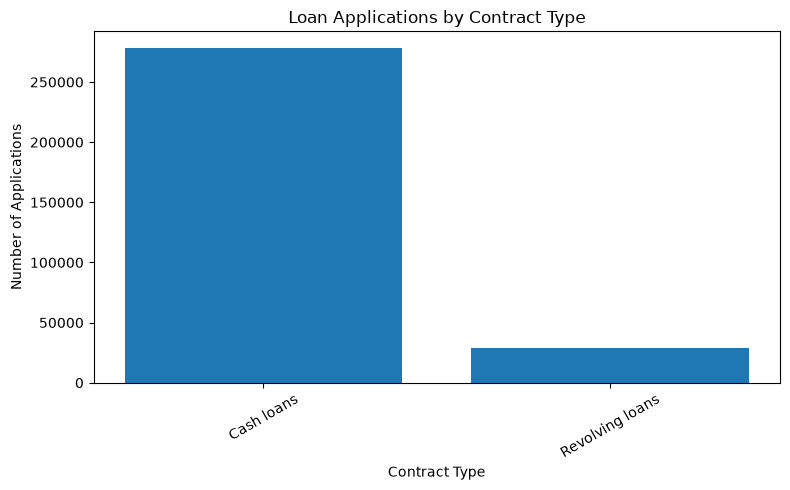

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    contract_type_summary[
        "NAME_CONTRACT_TYPE"
    ].astype(str),
    contract_type_summary[
        "Category_Count"
    ],
)

ax.set_title(
    "Loan Applications by Contract Type"
)
ax.set_xlabel("Contract Type")
ax.set_ylabel("Number of Applications")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

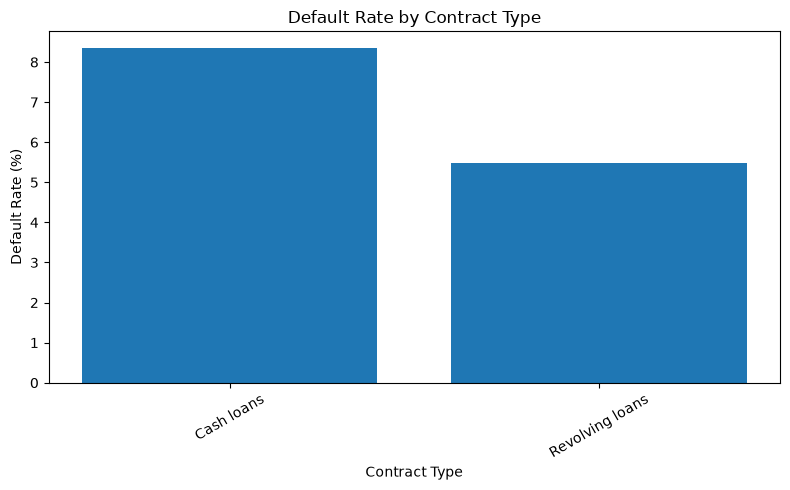

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    contract_type_summary[
        "NAME_CONTRACT_TYPE"
    ].astype(str),
    contract_type_summary[
        "Default_Rate"
    ],
)

ax.set_title(
    "Default Rate by Contract Type"
)
ax.set_xlabel("Contract Type")
ax.set_ylabel("Default Rate (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### <b>Observation</b>

The contract categories may have different application volumes and default rates.

A higher default rate in one category may indicate greater risk, but the result should be interpreted together with the number of applications and other customer characteristics.

#### <b>Step 7: Analyze Gender</b>

`CODE_GENDER` represents the applicant's recorded gender category.

We examine:

- Category frequencies
- Unexpected categories
- Default rates

Gender-related patterns must be handled carefully because this feature may raise fairness and regulatory concerns.

In [71]:
gender_summary = (
    create_category_target_summary(
        data=df,
        feature="CODE_GENDER",
    )
)

print(gender_summary)

  CODE_GENDER  Category_Count  Default_Count  Default_Rate  \
0           F          202448          14170          7.00   
1           M          105059          10655         10.14   
2         XNA               4              0          0.00   

   Category_Percentage  
0                65.83  
1                34.16  
2                 0.00  


##### <b>Data Quality Note</b>

If an unexpected category such as `XNA` appears, it should not automatically be treated as a valid gender category.

It may represent unknown or unavailable information and should be reviewed during preprocessing.

In [72]:
unexpected_gender_count = int(
    (df["CODE_GENDER"] == "XNA").sum()
)

print(
    "Number of records with CODE_GENDER = XNA:",
    unexpected_gender_count,
)

Number of records with CODE_GENDER = XNA: 4


##### <b>Fairness and Responsible Modeling Note</b>

Even if gender is associated with default rates, using it directly in lending decisions may raise fairness, ethical, and legal concerns.

A production system should evaluate:

- Whether the feature is legally permitted
- Whether it introduces disparate impact
- Whether model performance changes when it is removed
- Whether proxy variables reproduce the same bias

Predictive power alone is not sufficient justification for using a sensitive feature.

#### <b>Step 8: Analyze Car and Property Ownership</b>

The features:

- `FLAG_OWN_CAR`
- `FLAG_OWN_REALTY`

indicate whether the customer owns a car or real estate.

Ownership may reflect financial stability, but it does not directly prove repayment ability.

In [73]:
car_ownership_summary = (
    create_category_target_summary(
        data=df,
        feature="FLAG_OWN_CAR",
    )
)

property_ownership_summary = (
    create_category_target_summary(
        data=df,
        feature="FLAG_OWN_REALTY",
    )
)

print(car_ownership_summary)

  FLAG_OWN_CAR  Category_Count  Default_Count  Default_Rate  \
0            N          202924          17249          8.50   
1            Y          104587           7576          7.24   

   Category_Percentage  
0                65.99  
1                34.01  


In [74]:
print(property_ownership_summary)

  FLAG_OWN_REALTY  Category_Count  Default_Count  Default_Rate  \
0               Y          213312          16983          7.96   
1               N           94199           7842          8.32   

   Category_Percentage  
0                69.37  
1                30.63  


##### <b>Business Insight</b>

Car or property ownership may provide information about customer assets.

However:

- Ownership does not guarantee sufficient cash flow.
- A customer may own property but still have high debt.
- A customer without property may still have stable income.
- Ownership should be analyzed together with income, credit burden, and employment.

These variables should not be used as standalone approval rules.

#### <b>Step 9: Analyze Income Type</b>

`NAME_INCOME_TYPE` describes the customer's main source of income.

Income stability may vary across employment and income categories.

We compare category size and default rate.

In [75]:
income_type_summary = (
    create_category_target_summary(
        data=df,
        feature="NAME_INCOME_TYPE",
    )
)

print(income_type_summary)

       NAME_INCOME_TYPE  Category_Count  Default_Count  Default_Rate  \
0               Working          158774          15224          9.59   
1  Commercial associate           71617           5360          7.48   
2             Pensioner           55362           2982          5.39   
3         State servant           21703           1249          5.75   
4            Unemployed              22              8         36.36   
5               Student              18              0          0.00   
6           Businessman              10              0          0.00   
7       Maternity leave               5              2         40.00   

   Category_Percentage  
0                51.63  
1                23.29  
2                18.00  
3                 7.06  
4                 0.01  
5                 0.01  
6                 0.00  
7                 0.00  


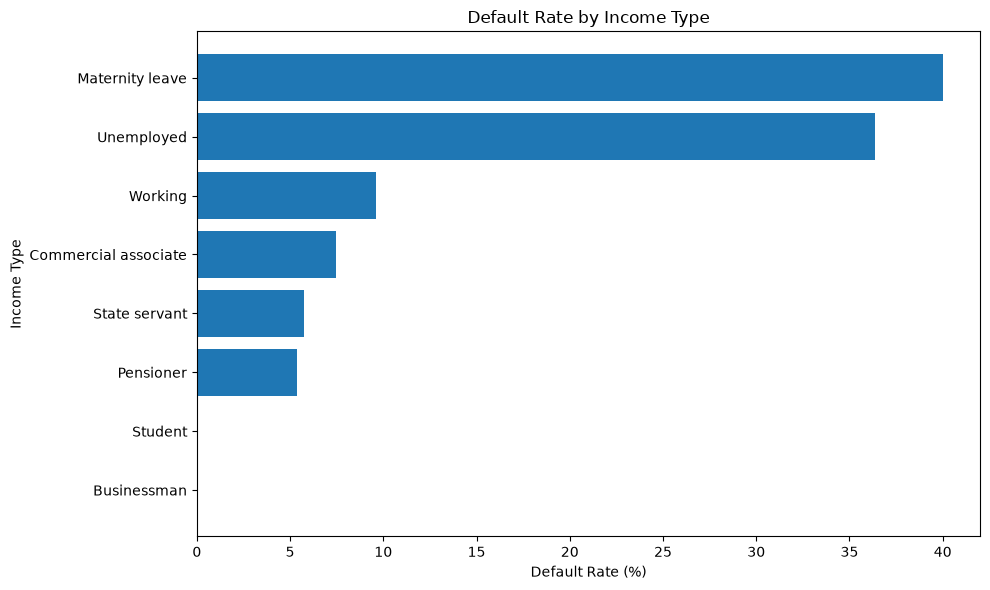

In [76]:
income_type_plot_data = (
    income_type_summary.sort_values(
        by="Default_Rate",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    income_type_plot_data[
        "NAME_INCOME_TYPE"
    ].astype(str),
    income_type_plot_data[
        "Default_Rate"
    ],
)

ax.set_title("Default Rate by Income Type")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Income Type")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Income-type categories may show different default rates.

However, categories with very few customers may produce unstable rates.

Before drawing conclusions, we should review both:

- `Category_Count`
- `Default_Rate`

#### <b>Step 10: Analyze Education Level</b>

`NAME_EDUCATION_TYPE` represents the applicant's reported education level.

Education may be related to occupation, income, and employment stability.

We analyze category frequency and default rate without assuming a causal relationship.

In [77]:
education_summary = (
    create_category_target_summary(
        data=df,
        feature="NAME_EDUCATION_TYPE",
    )
)

print(education_summary)

             NAME_EDUCATION_TYPE  Category_Count  Default_Count  Default_Rate  \
0  Secondary / secondary special          218391          19524          8.94   
1               Higher education           74863           4009          5.36   
2              Incomplete higher           10277            872          8.48   
3                Lower secondary            3816            417         10.93   
4                Academic degree             164              3          1.83   

   Category_Percentage  
0                71.02  
1                24.34  
2                 3.34  
3                 1.24  
4                 0.05  


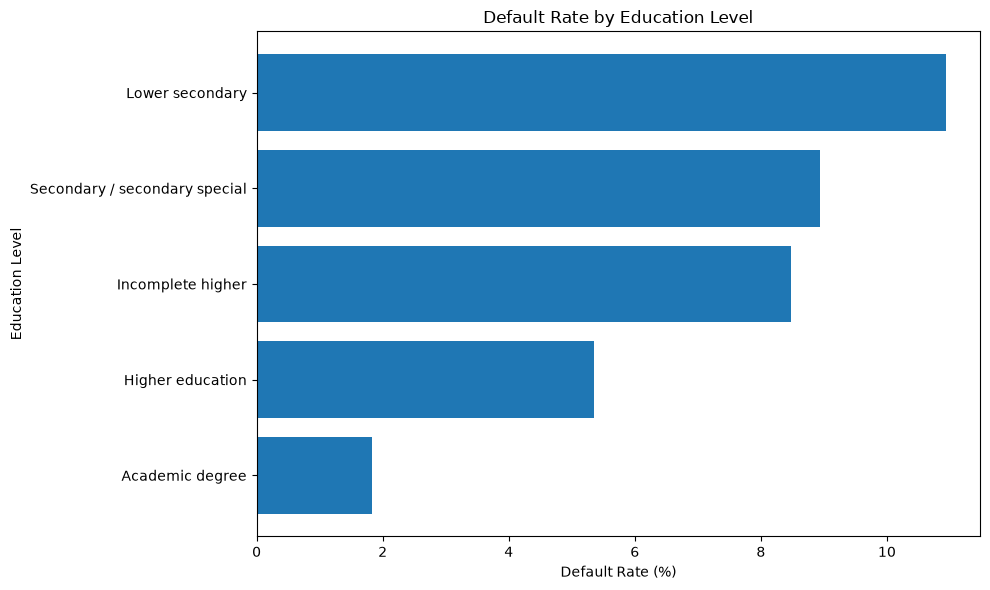

In [78]:
education_plot_data = (
    education_summary.sort_values(
        by="Default_Rate",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    education_plot_data[
        "NAME_EDUCATION_TYPE"
    ].astype(str),
    education_plot_data[
        "Default_Rate"
    ],
)

ax.set_title(
    "Default Rate by Education Level"
)
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Education Level")

plt.tight_layout()
plt.show()

##### <b>Interpretation</b>

Education categories may have different default rates, but education may also be associated with other variables such as:

- Income
- Occupation
- Age
- Employment type
- Credit history

Therefore, the relationship should be evaluated together with other features rather than interpreted independently.

#### <b>Step 11: Analyze Family Status</b>

`NAME_FAMILY_STATUS` describes the applicant's family or marital status.

Family status may be related to household size, financial responsibilities, and combined income.

In [79]:
family_status_summary = (
    create_category_target_summary(
        data=df,
        feature="NAME_FAMILY_STATUS",
    )
)

print(family_status_summary)

     NAME_FAMILY_STATUS  Category_Count  Default_Count  Default_Rate  \
0               Married          196432          14850          7.56   
1  Single / not married           45444           4457          9.81   
2        Civil marriage           29775           2961          9.94   
3             Separated           19770           1620          8.19   
4                 Widow           16088            937          5.82   
5               Unknown               2              0          0.00   

   Category_Percentage  
0                63.88  
1                14.78  
2                 9.68  
3                 6.43  
4                 5.23  
5                 0.00  


##### <b>Data Quality Note</b>

Unexpected categories such as `Unknown` should be reviewed.

An unknown category may contain useful information, but it may also represent incomplete data collection.

#### <b>Step 12: Analyze Housing Type</b>

`NAME_HOUSING_TYPE` describes the customer's housing situation.

Housing type may provide information about living stability and financial obligations.

In [80]:
housing_type_summary = (
    create_category_target_summary(
        data=df,
        feature="NAME_HOUSING_TYPE",
    )
)

print(housing_type_summary)

     NAME_HOUSING_TYPE  Category_Count  Default_Count  Default_Rate  \
0    House / apartment          272868          21272          7.80   
1         With parents           14840           1736         11.70   
2  Municipal apartment           11183            955          8.54   
3     Rented apartment            4881            601         12.31   
4     Office apartment            2617            172          6.57   
5      Co-op apartment            1122             89          7.93   

   Category_Percentage  
0                88.73  
1                 4.83  
2                 3.64  
3                 1.59  
4                 0.85  
5                 0.36  


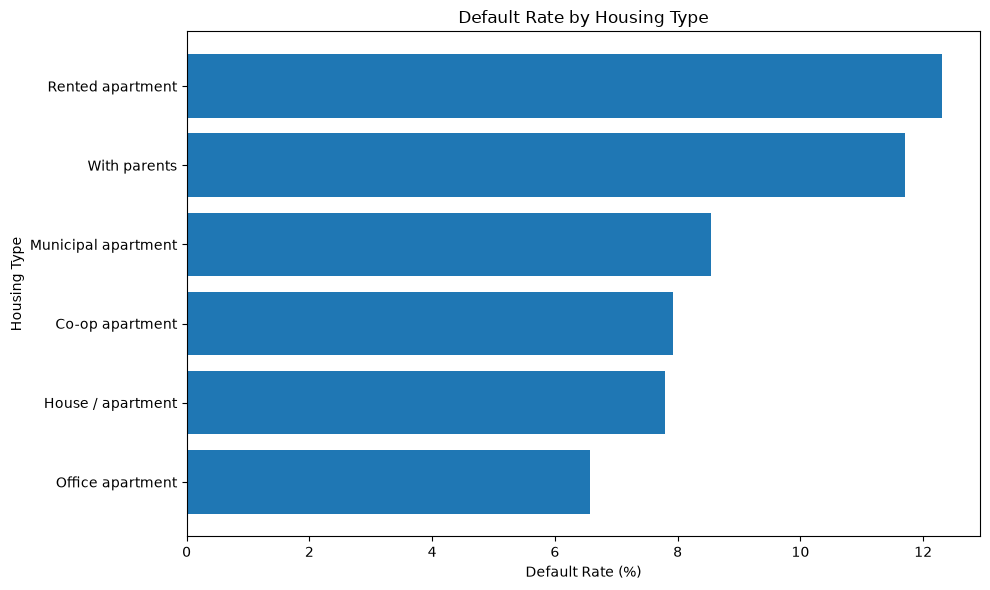

In [81]:
housing_plot_data = (
    housing_type_summary.sort_values(
        by="Default_Rate",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    housing_plot_data[
        "NAME_HOUSING_TYPE"
    ].astype(str),
    housing_plot_data[
        "Default_Rate"
    ],
)

ax.set_title("Default Rate by Housing Type")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Housing Type")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

Housing type may indicate different levels of financial stability or monthly expense.

For example, customers living with parents, renting, or owning a home may have different financial responsibilities.

However, housing type alone should not be interpreted as proof of creditworthiness.

#### <b>Step 13: Analyze Occupation Type</b>

`OCCUPATION_TYPE` describes the applicant's occupation category.

This feature may contain:

- Multiple occupation groups
- Missing values
- Rare categories
- Different default-rate patterns

Missing occupation information may itself carry predictive information.

In [82]:
occupation_summary = (
    create_category_target_summary(
        data=df,
        feature="OCCUPATION_TYPE",
    )
)

print(occupation_summary)

          OCCUPATION_TYPE  Category_Count  Default_Count  Default_Rate  \
0                 Missing           96391           6278          6.51   
1                Laborers           55186           5838         10.58   
2             Sales staff           32102           3092          9.63   
3              Core staff           27570           1738          6.30   
4                Managers           21371           1328          6.21   
5                 Drivers           18603           2107         11.33   
6   High skill tech staff           11380            701          6.16   
7             Accountants            9813            474          4.83   
8          Medicine staff            8537            572          6.70   
9          Security staff            6721            722         10.74   
10          Cooking staff            5946            621         10.44   
11         Cleaning staff            4653            447          9.61   
12  Private service staff            2

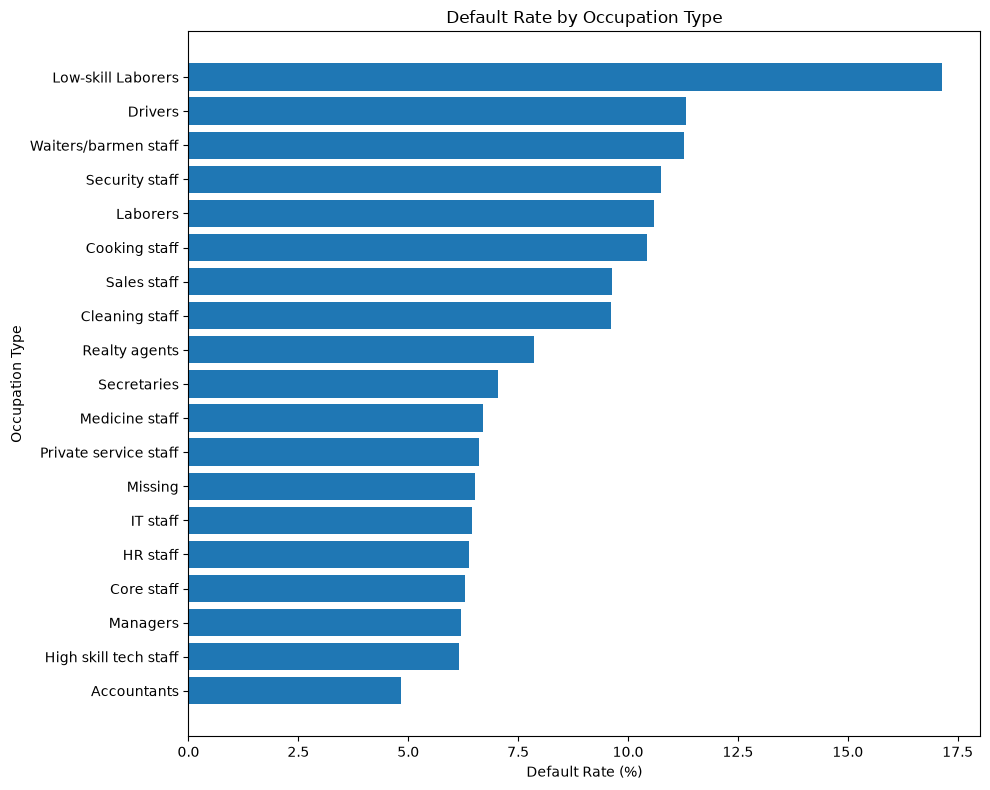

In [83]:
occupation_plot_data = (
    occupation_summary.sort_values(
        by="Default_Rate",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    occupation_plot_data[
        "OCCUPATION_TYPE"
    ].astype(str),
    occupation_plot_data[
        "Default_Rate"
    ],
)

ax.set_title("Default Rate by Occupation Type")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Occupation Type")

plt.tight_layout()
plt.show()

##### <b>Important Note</b>

A category with a high default rate should not automatically be labeled high-risk.

We must check whether the category contains enough observations.

A category with only a few customers may produce an unreliable default-rate estimate.

#### <b>Step 14: Analyze Organization Type</b>

`ORGANIZATION_TYPE` describes the type of organization where the customer works.

This feature can contain many categories and may therefore have relatively high cardinality.

In [84]:
organization_summary = (
    create_category_target_summary(
        data=df,
        feature="ORGANIZATION_TYPE",
    )
)

organization_summary.head(20)

,ORGANIZATION_TYPE,Category_Count,Default_Count,Default_Rate,Category_Percentage
0,Business Entity Type 3,67992,6323,9.30,22.11
1,XNA,55374,2990,5.40,18.01
2,Self-employed,38412,3908,10.17,12.49
3,Other,16683,1275,7.64,5.43
4,Medicine,11193,737,6.58,3.64
5,Business Entity Type 2,10553,900,8.53,3.43
6,Government,10404,726,6.98,3.38
7,School,8893,526,5.91,2.89
8,Trade: type 7,7831,740,9.45,2.55
9,Kindergarten,6880,484,7.03,2.24


##### <b>Encoding Challenge</b>

One-hot encoding a high-cardinality feature can create many additional columns.

Possible strategies include:

- Grouping rare categories into `Other`
- Frequency encoding
- Target encoding
- Native categorical handling
- Dropping the feature if it adds little predictive value

The final decision should be based on cross-validation and model performance.

#### <b>Step 15: Identify Rare Categories</b>

Rare categories contain only a small percentage of records.

They can create problems because:

- Their statistics may be unstable.
- They may cause overfitting.
- They can produce sparse one-hot encoded columns.
- Some categories may appear in training data but not test data.

For exploratory analysis, we define a rare category as one representing less than 1% of the dataset.

In [85]:
def identify_rare_categories(
    data: pd.DataFrame,
    feature: str,
    threshold: float = 0.01,
) -> pd.DataFrame:
    """
    Identify categories below a frequency threshold.

    Parameters
    ----------
    data:
        Input DataFrame.
    feature:
        Categorical feature.
    threshold:
        Minimum relative frequency required for
        a category not to be considered rare.

    Returns
    -------
    pd.DataFrame
        Rare-category frequency summary.
    """
    category_frequency = (
        data[feature]
        .fillna("Missing")
        .value_counts(normalize=True)
        .rename_axis(feature)
        .reset_index(name="Frequency")
    )

    category_frequency[
        "Percentage"
    ] = (
        category_frequency["Frequency"]
        * 100
    ).round(2)

    return category_frequency[
        category_frequency["Frequency"]
        < threshold
    ].reset_index(drop=True)

In [86]:
rare_organization_categories = (
    identify_rare_categories(
        data=df,
        feature="ORGANIZATION_TYPE",
        threshold=0.01,
    )
)

print(rare_organization_categories)

      ORGANIZATION_TYPE  Frequency  Percentage
0               Housing   0.009619        0.96
1     Industry: type 11   0.008793        0.88
2              Military   0.008566        0.86
3                  Bank   0.008153        0.82
4           Agriculture   0.007980        0.80
5                Police   0.007613        0.76
6     Transport: type 2   0.007167        0.72
7                Postal   0.007014        0.70
8   Security Ministries   0.006419        0.64
9         Trade: type 2   0.006179        0.62
10           Restaurant   0.005889        0.59
11             Services   0.005122        0.51
12           University   0.004315        0.43
13     Industry: type 7   0.004250        0.43
14    Transport: type 3   0.003860        0.39
15     Industry: type 1   0.003379        0.34
16                Hotel   0.003141        0.31
17          Electricity   0.003089        0.31
18     Industry: type 4   0.002852        0.29
19        Trade: type 6   0.002052        0.21
20     Indust

##### <b>Interpretation</b>

Rare categories may later be combined into an `Other` category.

However, grouping should not be done automatically.

A rare category may still have important business or predictive meaning.

#### <b>Step 16: Count Rare Categories Across Categorical Features</b>

We calculate how many categories in each categorical feature represent less than 1% of the dataset.

In [87]:
rare_category_summary_records = []

for column in categorical_columns:
    frequency = (
        df[column]
        .fillna("Missing")
        .value_counts(normalize=True)
    )

    rare_category_count = int(
        (frequency < 0.01).sum()
    )

    rare_category_summary_records.append(
        {
            "Column": column,
            "Total_Categories": int(
                len(frequency)
            ),
            "Rare_Categories_Below_1_Percent": (
                rare_category_count
            ),
        }
    )

rare_category_summary = pd.DataFrame(
    rare_category_summary_records
).sort_values(
    by="Rare_Categories_Below_1_Percent",
    ascending=False,
).reset_index(drop=True)

print(rare_category_summary)

                        Column  Total_Categories  \
0            ORGANIZATION_TYPE                58   
1              OCCUPATION_TYPE                19   
2             NAME_INCOME_TYPE                 8   
3              NAME_TYPE_SUITE                 8   
4           WALLSMATERIAL_MODE                 8   
5            NAME_HOUSING_TYPE                 6   
6               HOUSETYPE_MODE                 4   
7                  CODE_GENDER                 3   
8          NAME_EDUCATION_TYPE                 5   
9          EMERGENCYSTATE_MODE                 3   
10          NAME_FAMILY_STATUS                 6   
11             FLAG_OWN_REALTY                 2   
12                FLAG_OWN_CAR                 2   
13          NAME_CONTRACT_TYPE                 2   
14  WEEKDAY_APPR_PROCESS_START                 7   
15          FONDKAPREMONT_MODE                 5   

    Rare_Categories_Below_1_Percent  
0                                41  
1                                 7  
2

#### <b>Step 17: Identify Features with a Dominant Category</b>

A categorical feature may provide limited information when one category contains almost all records.

We identify features where the most frequent category represents more than 95% of the dataset.

In [88]:
dominant_category_features = (
    categorical_summary[
        categorical_summary[
            "Most_Frequent_Percentage"
        ] > 95
    ]
    .reset_index(drop=True)
)

print(dominant_category_features)

Empty DataFrame
Columns: [Column, Unique_Categories, Missing_Count, Missing_Percentage, Most_Frequent_Category, Most_Frequent_Count, Most_Frequent_Percentage]
Index: []


##### <b>Interpretation</b>

A feature dominated by one category may have low variance and limited predictive value.

However, it should not be dropped solely on this basis.

We should also check:

- Whether the minority category has a distinct default rate
- Whether the feature improves cross-validation performance
- Whether it has business importance

#### <b>Step 18: Compare Missing and Non-Missing Groups</b>

For categorical columns containing missing values, the absence of information may be associated with default risk.

We compare the default rate between:

- Missing values
- Available values

In [89]:
categorical_missing_target_records = []

for column in categorical_columns:
    if df[column].isnull().any():
        missing_indicator = (
            df[column].isnull()
        )

        missing_default_rate = (
            df.loc[
                missing_indicator,
                "TARGET",
            ].mean()
            * 100
        )

        available_default_rate = (
            df.loc[
                ~missing_indicator,
                "TARGET",
            ].mean()
            * 100
        )

        categorical_missing_target_records.append(
            {
                "Column": column,
                "Missing_Count": int(
                    missing_indicator.sum()
                ),
                "Missing_Default_Rate": round(
                    missing_default_rate,
                    2,
                ),
                "Available_Default_Rate": round(
                    available_default_rate,
                    2,
                ),
                "Default_Rate_Difference": round(
                    missing_default_rate
                    - available_default_rate,
                    2,
                ),
            }
        )

categorical_missing_target_summary = (
    pd.DataFrame(
        categorical_missing_target_records
    )
    .sort_values(
        by="Default_Rate_Difference",
        key=lambda values: values.abs(),
        ascending=False,
    )
    .reset_index(drop=True)
)

print(categorical_missing_target_summary)

                Column  Missing_Count  Missing_Default_Rate  \
0      NAME_TYPE_SUITE           1292                  5.42   
1      OCCUPATION_TYPE          96391                  6.51   
2  EMERGENCYSTATE_MODE         145755                  9.26   
3       HOUSETYPE_MODE         154297                  9.15   
4   WALLSMATERIAL_MODE         156341                  9.13   
5   FONDKAPREMONT_MODE         210295                  8.62   

   Available_Default_Rate  Default_Rate_Difference  
0                    8.08                    -2.67  
1                    8.79                    -2.27  
2                    7.00                     2.26  
3                    6.99                     2.16  
4                    6.98                     2.15  
5                    6.89                     1.73  


##### <b>Business Insight</b>

If missing and available groups have different default rates, missingness may carry predictive information.

In such cases, using a separate `Missing` or `Unknown` category may be more useful than replacing missing values with the most frequent category.

However, the result must be validated during model training.

#### <b>Step 19: Check for Inconsistent Text Categories</b>

Categorical columns may contain data-quality problems such as:

- Leading spaces
- Trailing spaces
- Different capitalization
- Empty strings
- Different spellings for the same category

We perform a basic check for leading and trailing whitespace.

In [90]:
whitespace_issue_records = []

for column in categorical_columns:
    non_missing_values = (
        df[column]
        .dropna()
        .astype(str)
    )

    whitespace_count = int(
        (
            non_missing_values
            != non_missing_values.str.strip()
        ).sum()
    )

    whitespace_issue_records.append(
        {
            "Column": column,
            "Whitespace_Issue_Count": (
                whitespace_count
            ),
        }
    )

whitespace_issue_summary = pd.DataFrame(
    whitespace_issue_records
).sort_values(
    by="Whitespace_Issue_Count",
    ascending=False,
).reset_index(drop=True)

whitespace_issue_summary.head(20)

,Column,Whitespace_Issue_Count
0,NAME_CONTRACT_TYPE,0
1,CODE_GENDER,0
2,FLAG_OWN_CAR,0
3,FLAG_OWN_REALTY,0
4,NAME_TYPE_SUITE,0
5,NAME_INCOME_TYPE,0
6,NAME_EDUCATION_TYPE,0
7,NAME_FAMILY_STATUS,0
8,NAME_HOUSING_TYPE,0
9,OCCUPATION_TYPE,0


In [91]:
empty_string_records = []

for column in categorical_columns:
    empty_string_count = int(
        (
            df[column]
            .fillna("")
            .astype(str)
            .str.strip()
            == ""
        ).sum()
    )

    missing_count = int(
        df[column].isnull().sum()
    )

    actual_empty_string_count = (
        empty_string_count - missing_count
    )

    empty_string_records.append(
        {
            "Column": column,
            "Empty_String_Count": max(
                actual_empty_string_count,
                0,
            ),
        }
    )

empty_string_summary = pd.DataFrame(
    empty_string_records
).sort_values(
    by="Empty_String_Count",
    ascending=False,
).reset_index(drop=True)

empty_string_summary.head(20)

,Column,Empty_String_Count
0,NAME_CONTRACT_TYPE,0
1,CODE_GENDER,0
2,FLAG_OWN_CAR,0
3,FLAG_OWN_REALTY,0
4,NAME_TYPE_SUITE,0
5,NAME_INCOME_TYPE,0
6,NAME_EDUCATION_TYPE,0
7,NAME_FAMILY_STATUS,0
8,NAME_HOUSING_TYPE,0
9,OCCUPATION_TYPE,0


#### <b>Step 20: Preliminary Categorical Encoding Strategy</b>

Based on the categorical analysis, the following strategies may be evaluated later.

##### Binary Categories

Examples:

- `FLAG_OWN_CAR`
- `FLAG_OWN_REALTY`

Possible method:

- Binary mapping such as `Y = 1`, `N = 0`

##### Low-Cardinality Nominal Features

Examples:

- Contract type
- Housing type
- Family status

Possible method:

- One-hot encoding

##### Ordinal Features

Examples may include education categories if a valid business order is defined.

Possible method:

- Ordinal encoding using a documented category order

##### High-Cardinality Features

Examples:

- Organization type
- Occupation type

Possible methods:

- Rare-category grouping
- Frequency encoding
- Target encoding with cross-validation
- Native categorical handling

##### Missing Categories

Possible methods:

- Add an `Unknown` or `Missing` category
- Add a missing-value indicator
- Use business-specific treatment

##### <b>Important: Prevent Data Leakage During Categorical Encoding</b>

Encoding parameters must be learned from the training data only.

For example:

- One-hot categories should be fitted on training data.
- Frequency values should be calculated from training data.
- Target encoding must use training labels only.
- Validation and test data must not influence category statistics.

Target encoding is particularly risky because it directly uses the target variable.

It should be implemented using out-of-fold or cross-validation-based methods.

##### <b>Important: Fairness and Ethical Considerations</b>

Some categorical features may represent sensitive or protected information.

Even when such a feature improves model performance, its use may introduce:

- Discrimination
- Disparate impact
- Regulatory risk
- Unfair lending decisions

The model should be evaluated for fairness across relevant demographic groups.

Sensitive features may also be retained for fairness auditing even if they are excluded from model training.

#### <b>Business Insights</b>

1. Categorical features describe important demographic, employment, housing, and loan characteristics.
2. Category frequency and category-level default rate provide different information.
3. Rare categories may produce unstable default-rate estimates.
4. High-cardinality features require careful encoding.
5. Missing categorical information may itself be related to default risk.
6. A dominant category does not automatically make a feature useless.
7. Some unexpected categories may represent data-quality problems.
8. Sensitive demographic variables require fairness and regulatory review.
9. No categorical feature should be used as a standalone loan-approval rule.
10. Encoding methods must be fitted only on training data to prevent leakage.

#### <b>Session 5 Summary</b>

In this session, we:

- Identified categorical features
- Created a categorical summary table
- Measured categorical cardinality
- Analyzed important business-related categories
- Compared category frequencies and default rates
- Identified rare categories
- Detected dominant categories
- Compared missing and non-missing default rates
- Checked inconsistent text values
- Discussed encoding strategies
- Reviewed data-leakage risks
- Discussed fairness and responsible lending concerns

No categorical feature was permanently modified or encoded during this session.

The next session will focus on bivariate and multivariate analysis.

### <b>Session 6: Outlier Analysis</b>

**Objective**

The objective of this session is to identify and analyze extreme numerical values in the loan-default dataset.

We will study:

- What an outlier is
- Why outliers occur
- Statistical methods for detecting outliers
- Business validation of extreme values
- Outlier distributions across important numerical features
- Differences between genuine extreme values and data-quality errors
- Preliminary strategies for handling outliers

No outlier will be permanently removed or transformed during this EDA session.

#### <b>Business Context</b>

Loan application datasets commonly contain extreme values.

Examples include:

- Very high customer income
- Very large loan amounts
- Unusually high annuity payments
- Large family sizes
- Very long employment periods
- Unexpected placeholder values

An extreme value is not automatically an error.

For example:

- A customer may genuinely have a very high income.
- A large loan may be valid for a high-income customer.
- A large family may be uncommon but possible.
- An impossible employment duration may indicate a placeholder or data-entry problem.

Therefore, outlier analysis must combine statistical methods with business understanding.

#### <b>Step 1: What Is an Outlier?</b>

An outlier is an observation that lies unusually far from most other observations in a numerical feature.

Outliers may occur because of:

1. Genuine rare cases
2. Data-entry errors
3. Measurement errors
4. Missing-value placeholders
5. Different customer segments
6. Fraudulent or abnormal applications
7. Natural variation in financial data

Outliers should be investigated before they are removed.

#### <b>Step 2: Select Important Numerical Features</b>

We will focus on business-relevant numerical features such as:

- Customer income
- Credit amount
- Annuity amount
- Goods price
- Age
- Employment duration
- Number of children
- Number of family members
- External credit scores

In [92]:
important_numerical_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_numerical_features = [
    column
    for column in important_numerical_features
    if column in df.columns
]

print("Selected numerical features:")
print(available_numerical_features)

Selected numerical features:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


#### <b>Step 3: Create Interpretable Features</b>

Some features are stored in a format that is difficult to interpret.

For exploratory analysis, we create:

- Age in years
- Employment duration in years

The special employment value `365243` will be treated separately because it does not represent a realistic employment duration.

In [93]:
outlier_df = df.copy()

outlier_df["AGE_YEARS"] = (
    -outlier_df["DAYS_BIRTH"] / 365.25
)

outlier_df["EMPLOYMENT_YEARS"] = np.where(
    outlier_df["DAYS_EMPLOYED"] == 365243,
    np.nan,
    -outlier_df["DAYS_EMPLOYED"] / 365.25,
)

#### <b>Step 4: Create an Extreme-Value Summary</b>

For each selected numerical feature, we calculate:

- Minimum
- First percentile
- First quartile
- Median
- Third quartile
- Ninety-ninth percentile
- Maximum
- Mean
- Standard deviation
- Skewness

This helps us identify features with unusually large ranges or strongly skewed distributions.

In [94]:
outlier_summary_records = []

analysis_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_analysis_features = [
    column
    for column in analysis_features
    if column in outlier_df.columns
]

for column in available_analysis_features:
    series = outlier_df[column].dropna()

    outlier_summary_records.append(
        {
            "Feature": column,
            "Minimum": series.min(),
            "P01": series.quantile(0.01),
            "Q1": series.quantile(0.25),
            "Median": series.median(),
            "Q3": series.quantile(0.75),
            "P99": series.quantile(0.99),
            "Maximum": series.max(),
            "Mean": series.mean(),
            "Standard_Deviation": series.std(),
            "Skewness": series.skew(),
        }
    )

outlier_summary = pd.DataFrame(
    outlier_summary_records
).round(3)

outlier_summary

,Feature,Minimum,P01,Q1,Median,Q3,P99,Maximum,Mean,Standard_Deviation,Skewness
0,AMT_INCOME_TOTAL,25650.000,45000.000,112500.000,147150.000,202500.000,472500.000,1.170000e+08,168797.919,237123.146,391.560
1,AMT_CREDIT,45000.000,76410.000,270000.000,513531.000,808650.000,1854000.000,4.050000e+06,599026.000,402490.777,1.235
2,AMT_ANNUITY,1615.500,6182.910,16524.000,24903.000,34596.000,70006.500,2.580255e+05,27108.574,14493.737,1.580
3,AMT_GOODS_PRICE,40500.000,67500.000,238500.000,450000.000,679500.000,1800000.000,4.050000e+06,538396.207,369446.461,1.349
4,AGE_YEARS,20.504,22.623,33.985,43.121,53.886,66.856,6.907300e+01,43.907,11.948,0.116
5,EMPLOYMENT_YEARS,0.000,0.304,2.100,4.512,8.693,31.043,4.904000e+01,6.527,6.402,1.968
6,CNT_CHILDREN,0.000,0.000,0.000,0.000,1.000,3.000,1.900000e+01,0.417,0.722,1.975
7,CNT_FAM_MEMBERS,1.000,1.000,2.000,2.000,3.000,5.000,2.000000e+01,2.153,0.911,0.988
8,EXT_SOURCE_1,0.015,0.084,0.334,0.506,0.675,0.889,9.630000e-01,0.502,0.211,-0.069
9,EXT_SOURCE_2,0.000,0.029,0.392,0.566,0.664,0.783,8.550000e-01,0.514,0.191,-0.794


##### <b>Observation</b>

Features such as income, credit amount, annuity, and goods price may have maximum values much larger than their medians.

This may indicate:

- Positive skewness
- Genuine high-value customers
- Potential outliers
- Possible data-quality issues

The maximum value alone is not sufficient to decide whether a record should be removed.

#### <b>Step 5: IQR-Based Outlier Detection</b>

The Interquartile Range method uses the middle 50% of the data.

The formulas are:

\[
IQR = Q3 - Q1
\]

\[
Lower\ Bound = Q1 - 1.5 \times IQR
\]

\[
Upper\ Bound = Q3 + 1.5 \times IQR
\]

Values outside these bounds are considered statistical outliers.

This method is robust because it uses quartiles instead of the mean and standard deviation.

In [95]:
def calculate_iqr_outlier_summary(
    data: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    """
    Calculate IQR-based outlier statistics.

    Parameters
    ----------
    data:
        Input DataFrame.
    features:
        Numerical features to analyze.

    Returns
    -------
    pd.DataFrame
        IQR bounds and outlier counts.
    """
    records = []

    for feature in features:
        if feature not in data.columns:
            continue

        series = data[feature].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        lower_outliers = int(
            (series < lower_bound).sum()
        )

        upper_outliers = int(
            (series > upper_bound).sum()
        )

        total_outliers = (
            lower_outliers + upper_outliers
        )

        records.append(
            {
                "Feature": feature,
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "Lower_Bound": lower_bound,
                "Upper_Bound": upper_bound,
                "Lower_Outliers": lower_outliers,
                "Upper_Outliers": upper_outliers,
                "Total_Outliers": total_outliers,
                "Outlier_Percentage": (
                    total_outliers
                    / len(series)
                    * 100
                ),
            }
        )

    return pd.DataFrame(records).round(3)

In [96]:
iqr_outlier_summary = (
    calculate_iqr_outlier_summary(
        data=outlier_df,
        features=available_analysis_features,
    )
)

iqr_outlier_summary.sort_values(
    by="Outlier_Percentage",
    ascending=False,
).reset_index(drop=True)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Lower_Outliers,Upper_Outliers,Total_Outliers,Outlier_Percentage
0,EMPLOYMENT_YEARS,2.100,8.693,6.593,-7.789,18.582,0,15149,15149,6.008
1,AMT_GOODS_PRICE,238500.000,679500.000,441000.000,-423000.000,1341000.000,0,14728,14728,4.794
2,AMT_INCOME_TOTAL,112500.000,202500.000,90000.000,-22500.000,337500.000,0,14035,14035,4.564
3,AMT_ANNUITY,16524.000,34596.000,18072.000,-10584.000,61704.000,0,7504,7504,2.440
4,AMT_CREDIT,270000.000,808650.000,538650.000,-537975.000,1616625.000,0,6562,6562,2.134
5,CNT_CHILDREN,0.000,1.000,1.000,-1.500,2.500,0,4272,4272,1.389
6,CNT_FAM_MEMBERS,2.000,3.000,1.000,0.500,4.500,0,4007,4007,1.303
7,AGE_YEARS,33.985,53.886,19.901,4.133,83.739,0,0,0,0.000
8,EXT_SOURCE_1,0.334,0.675,0.341,-0.178,1.187,0,0,0,0.000
9,EXT_SOURCE_2,0.392,0.664,0.271,-0.014,1.070,0,0,0,0.000


##### <b>Important Limitation of the IQR Method</b>

The IQR method identifies statistical outliers, but it does not determine whether a value is invalid.

In strongly skewed financial data, many genuine observations may lie above the upper IQR bound.

Therefore, IQR results should be treated as investigation signals rather than automatic deletion rules.

#### <b>Step 6: Visualize Potential Outliers</b>

Box plots help visualize:

- Median
- First and third quartiles
- Interquartile range
- Spread
- Potential outliers

We create a reusable plotting function.

In [97]:
def plot_feature_boxplot(
    data: pd.DataFrame,
    feature: str,
    title: str | None = None,
) -> None:
    """
    Display a horizontal box plot for a numerical feature.

    Parameters
    ----------
    data:
        Input DataFrame.
    feature:
        Numerical feature to plot.
    title:
        Optional plot title.
    """
    if feature not in data.columns:
        raise KeyError(
            f"Feature '{feature}' was not found."
        )

    plot_data = data[feature].dropna()

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.boxplot(
        plot_data,
        vert=False,
    )

    ax.set_title(
        title or f"Box Plot of {feature}"
    )
    ax.set_xlabel(feature)

    plt.tight_layout()
    plt.show()

#### <b>Step 7: Analyze Customer Income</b>

`AMT_INCOME_TOTAL` represents the applicant's reported total income.

Income data is often positively skewed because most customers have moderate income while a small number have very high income.

In [98]:
income_statistics = (
    outlier_df["AMT_INCOME_TOTAL"]
    .describe(
        percentiles=[
            0.90,
            0.95,
            0.99,
            0.995,
            0.999,
        ]
    )
)

print(income_statistics)

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
50%      1.471500e+05
90%      2.700000e+05
95%      3.375000e+05
99%      4.725000e+05
99.5%    6.300000e+05
99.9%    9.000000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


C:\Users\abhil\AppData\Local\Temp\ipykernel_1796\2729690468.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


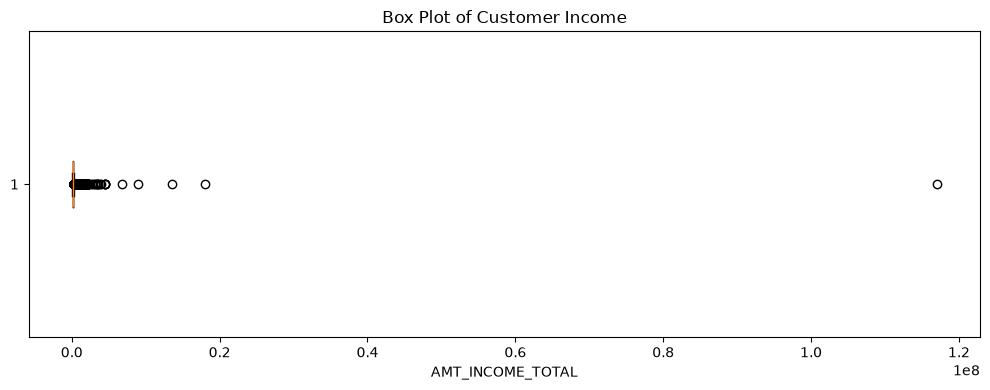

In [99]:
plot_feature_boxplot(
    data=outlier_df,
    feature="AMT_INCOME_TOTAL",
    title="Box Plot of Customer Income",
)

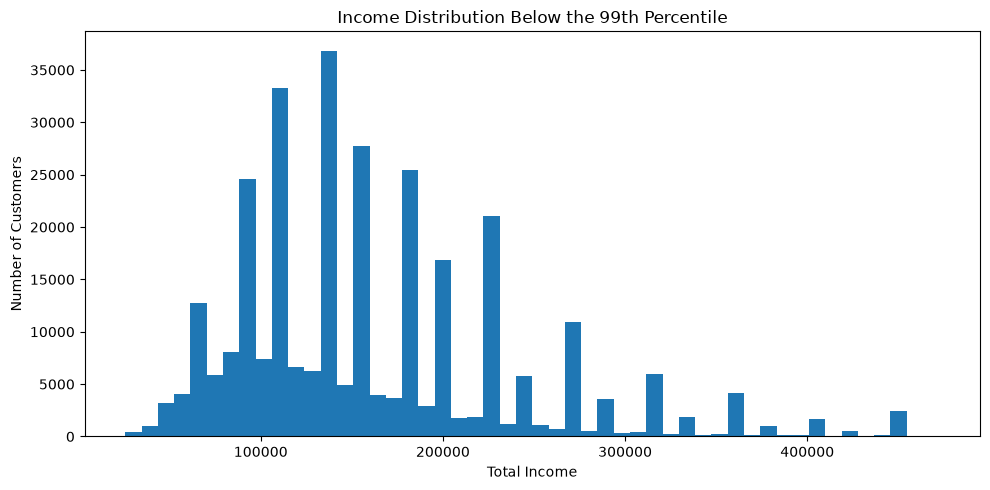

In [100]:
income_99th_percentile = (
    outlier_df["AMT_INCOME_TOTAL"]
    .quantile(0.99)
)

income_plot_data = outlier_df.loc[
    outlier_df["AMT_INCOME_TOTAL"]
    <= income_99th_percentile,
    "AMT_INCOME_TOTAL",
].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    income_plot_data,
    bins=50,
)

ax.set_title(
    "Income Distribution Below the 99th Percentile"
)
ax.set_xlabel("Total Income")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Business Interpretation</b>

Extremely high income values should not be removed automatically.

They may represent:

- Senior executives
- Business owners
- High-net-worth customers
- Annual income recorded under a different reporting convention
- Data-entry errors

We should examine the associated customer records and compare income with occupation, loan size, and annuity.

#### <b>Step 8: Inspect High-Income Customer Records</b>

We inspect records with the highest reported incomes to determine whether the values appear consistent with other customer characteristics.

In [101]:
income_review_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "NAME_INCOME_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "TARGET",
]

available_income_review_columns = [
    column
    for column in income_review_columns
    if column in outlier_df.columns
]

highest_income_records = (
    outlier_df[
        available_income_review_columns
    ]
    .sort_values(
        by="AMT_INCOME_TOTAL",
        ascending=False,
    )
    .head(20)
)

highest_income_records

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,TARGET
12840,117000000.0,562491.0,26194.5,Working,Laborers,Business Entity Type 3,1
203693,18000090.0,675000.0,69295.5,Commercial associate,NaN,Business Entity Type 3,0
246858,13500000.0,1400503.5,130945.5,Commercial associate,NaN,Business Entity Type 3,0
77768,9000000.0,1431531.0,132601.5,Working,Managers,Business Entity Type 1,0
131127,6750000.0,790830.0,52978.5,Working,Laborers,Transport: type 4,0
103006,4500000.0,2250000.0,225000.0,Working,Managers,Construction,0
287463,4500000.0,1755000.0,61132.5,Working,Managers,Self-employed,0
187833,4500000.0,835380.0,42651.0,Working,Laborers,Construction,0
204564,4500000.0,450000.0,47749.5,Working,Managers,Military,0
181698,3950059.5,675000.0,66217.5,Commercial associate,Managers,Trade: type 2,0


##### <b>Interpretation</b>

When reviewing extreme income records, we should check whether:

- Credit amounts are also high
- Annuity values are financially plausible
- Income type is consistent
- Occupation or organization provides context
- The same extreme value appears repeatedly
- The record belongs to the default class

This analysis may help distinguish valid wealthy customers from suspicious data entries.

#### <b>Step 9: Analyze Credit Amount</b>

`AMT_CREDIT` represents the total loan amount.

Large credit values may be genuine because loan products can vary significantly in size.

In [102]:
outlier_df["AMT_CREDIT"].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
    ]
)

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
50%      5.135310e+05
90%      1.133748e+06
95%      1.350000e+06
99%      1.854000e+06
99.5%    2.022566e+06
99.9%    2.517300e+06
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

C:\Users\abhil\AppData\Local\Temp\ipykernel_1796\2729690468.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


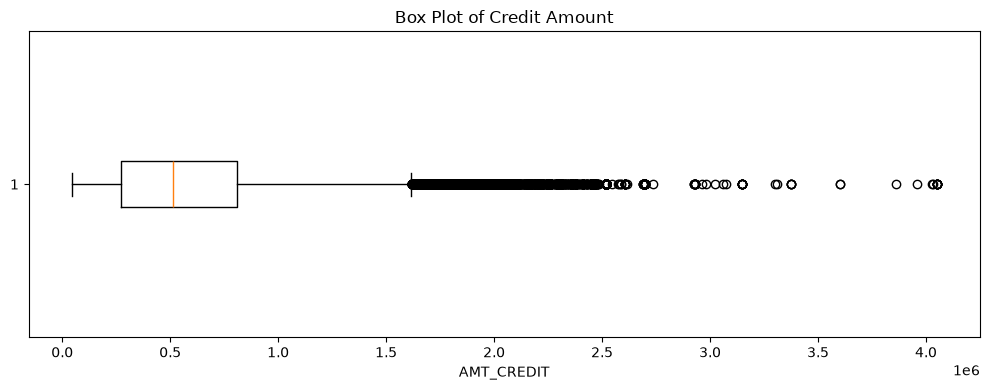

In [103]:
plot_feature_boxplot(
    data=outlier_df,
    feature="AMT_CREDIT",
    title="Box Plot of Credit Amount",
)

##### <b>Business Insight</b>

A large credit amount is not automatically risky.

Its risk depends on:

- Customer income
- Repayment amount
- Loan duration
- Goods price
- Employment stability
- Existing financial obligations
- External credit scores

Ratio features such as credit-to-income may be more informative than credit amount alone.

#### <b>Step 10: Analyze Annuity Amount</b>

`AMT_ANNUITY` represents the customer's periodic loan repayment amount.

Large annuity values may indicate either:

- A large loan
- A short repayment term
- High repayment pressure
- An unusual or incorrect value

In [104]:
outlier_df["AMT_ANNUITY"].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
    ]
)

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
50%       24903.000000
90%       45954.000000
95%       53325.000000
99%       70006.500000
99.5%     79758.000000
99.9%    110047.500000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

C:\Users\abhil\AppData\Local\Temp\ipykernel_1796\2729690468.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


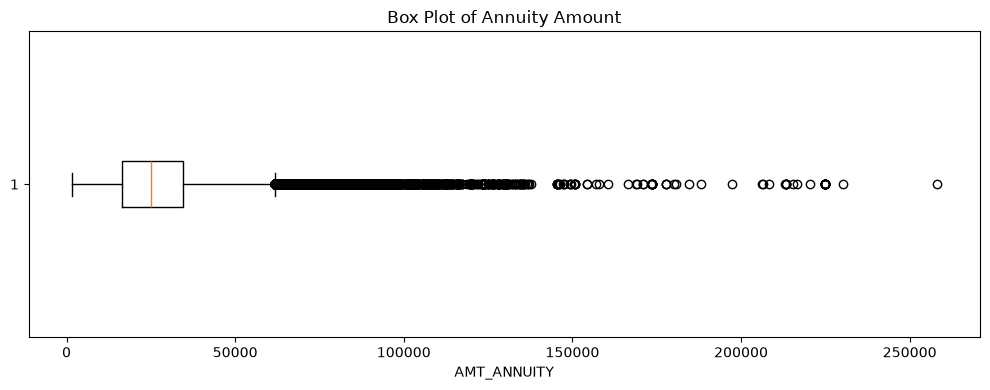

In [105]:
plot_feature_boxplot(
    data=outlier_df,
    feature="AMT_ANNUITY",
    title="Box Plot of Annuity Amount",
)

#### <b>Step 11: Analyze Goods Price</b>

`AMT_GOODS_PRICE` represents the price of the goods financed by the loan.

The feature is expected to be strongly related to the credit amount.

In [106]:
outlier_df["AMT_GOODS_PRICE"].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
    ]
)

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
50%      4.500000e+05
90%      1.093500e+06
95%      1.305000e+06
99%      1.800000e+06
99.5%    1.800000e+06
99.9%    2.250000e+06
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

C:\Users\abhil\AppData\Local\Temp\ipykernel_1796\2729690468.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


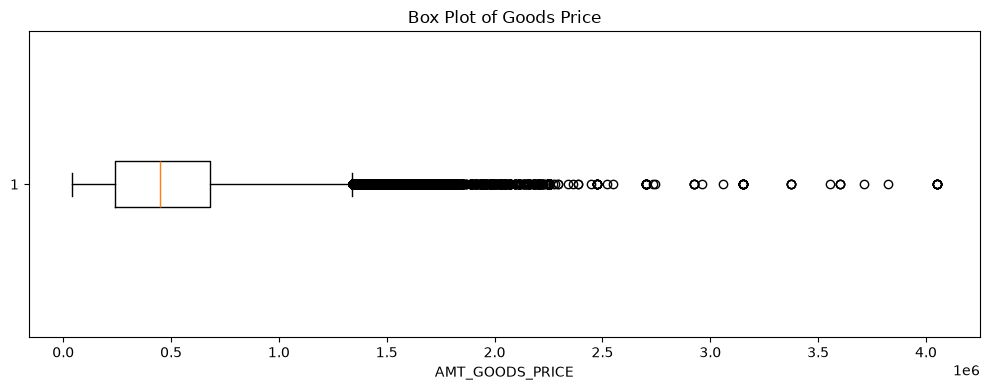

In [107]:
plot_feature_boxplot(
    data=outlier_df,
    feature="AMT_GOODS_PRICE",
    title="Box Plot of Goods Price",
)

##### <b>Data-Quality Check</b>

We should investigate cases where:

- Goods price is zero or negative
- Credit amount is much larger than goods price
- Goods price is missing while credit is available
- Credit and goods price differ unexpectedly

These cases may be valid depending on loan type, but they require further analysis.

In [108]:
goods_price_quality_check = {
    "Zero_Goods_Price": int(
        (
            outlier_df["AMT_GOODS_PRICE"]
            == 0
        ).sum()
    ),
    "Negative_Goods_Price": int(
        (
            outlier_df["AMT_GOODS_PRICE"]
            < 0
        ).sum()
    ),
    "Missing_Goods_Price": int(
        outlier_df[
            "AMT_GOODS_PRICE"
        ].isnull().sum()
    ),
}

goods_price_quality_check

{'Zero_Goods_Price': 0, 'Negative_Goods_Price': 0, 'Missing_Goods_Price': 278}

#### <b>Step 12: Validate Customer Age</b>

Age should fall within a realistic lending range.

We convert `DAYS_BIRTH` to years and inspect the minimum and maximum ages.

In [109]:
outlier_df["AGE_YEARS"].describe(
    percentiles=[
        0.01,
        0.05,
        0.95,
        0.99,
    ]
)

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
1%           22.622861
5%           25.754962
50%          43.121150
95%          63.529090
99%          66.855578
max          69.073238
Name: AGE_YEARS, dtype: float64

In [110]:
invalid_age_records = outlier_df.loc[
    (
        outlier_df["AGE_YEARS"] < 18
    )
    | (
        outlier_df["AGE_YEARS"] > 100
    ),
    [
        "DAYS_BIRTH",
        "AGE_YEARS",
        "TARGET",
    ],
]

print(
    "Potentially invalid age records:",
    len(invalid_age_records),
)

invalid_age_records.head()

Potentially invalid age records: 0


,DAYS_BIRTH,AGE_YEARS,TARGET


##### <b>Interpretation</b>

Unlike income, age has clear physical and legal boundaries.

Values below the legal lending age or above a realistic human age are more likely to represent data-quality problems.

Domain validation is therefore more useful than purely statistical outlier rules for age.

#### <b>Step 13: Investigate the `DAYS_EMPLOYED` Placeholder</b>

The value `365243` is an important anomaly in the dataset.

If interpreted literally, it represents approximately 1,000 years, which is impossible.

This value is likely a special placeholder for unavailable or non-applicable employment history.

In [111]:
employment_placeholder = 365243

employment_placeholder_count = int(
    (
        outlier_df["DAYS_EMPLOYED"]
        == employment_placeholder
    ).sum()
)

employment_placeholder_percentage = (
    employment_placeholder_count
    / len(outlier_df)
    * 100
)

print(
    "Placeholder count:",
    employment_placeholder_count,
)

print(
    "Placeholder percentage:",
    round(
        employment_placeholder_percentage,
        2,
    ),
)

Placeholder count: 55374
Placeholder percentage: 18.01


In [112]:
placeholder_mask = (
    outlier_df["DAYS_EMPLOYED"]
    == employment_placeholder
)

placeholder_default_rate = (
    outlier_df.loc[
        placeholder_mask,
        "TARGET",
    ].mean()
    * 100
)

valid_employment_default_rate = (
    outlier_df.loc[
        ~placeholder_mask,
        "TARGET",
    ].mean()
    * 100
)

employment_placeholder_summary = pd.DataFrame(
    {
        "Group": [
            "Placeholder",
            "Valid Employment Value",
        ],
        "Customer_Count": [
            int(placeholder_mask.sum()),
            int((~placeholder_mask).sum()),
        ],
        "Default_Rate": [
            placeholder_default_rate,
            valid_employment_default_rate,
        ],
    }
).round(2)

employment_placeholder_summary

,Group,Customer_Count,Default_Rate
0,Placeholder,55374,5.40
1,Valid Employment Value,252137,8.66


##### <b>Preliminary Strategy</b>

During preprocessing, the placeholder may be handled by:

1. Replacing `365243` with a missing value
2. Creating a binary indicator such as `DAYS_EMPLOYED_ANOMALOUS`
3. Converting valid employment duration into years
4. Allowing the model to learn whether the anomaly itself is informative

This preserves potentially useful missingness information.

#### <b>Step 14: Check Employment Duration Against Age</b>

Employment duration should not normally exceed customer age.

We identify potentially inconsistent records.

In [113]:
employment_age_inconsistency = (
    outlier_df.loc[
        outlier_df["EMPLOYMENT_YEARS"].notna()
        & (
            outlier_df["EMPLOYMENT_YEARS"]
            > outlier_df["AGE_YEARS"]
        ),
        [
            "AGE_YEARS",
            "EMPLOYMENT_YEARS",
            "DAYS_BIRTH",
            "DAYS_EMPLOYED",
            "TARGET",
        ],
    ]
)

print(
    "Employment duration greater than age:",
    len(employment_age_inconsistency),
)

employment_age_inconsistency.head()

Employment duration greater than age: 0


,AGE_YEARS,EMPLOYMENT_YEARS,DAYS_BIRTH,DAYS_EMPLOYED,TARGET


##### <b>Stronger Business Validation</b>

Employment duration should also not exceed the number of years since a realistic working age.

For example: Maximum\ plausible\ employment = Age - 14

This threshold is only exploratory and should be confirmed using business rules and geography-specific legal requirements.

In [114]:
minimum_working_age = 14

employment_since_working_age_issue = (
    outlier_df.loc[
        outlier_df["EMPLOYMENT_YEARS"].notna()
        & (
            outlier_df["EMPLOYMENT_YEARS"]
            >
            (
                outlier_df["AGE_YEARS"]
                - minimum_working_age
            )
        ),
        [
            "AGE_YEARS",
            "EMPLOYMENT_YEARS",
            "TARGET",
        ],
    ]
)

print(
    "Potential employment-age inconsistencies:",
    len(employment_since_working_age_issue),
)

Potential employment-age inconsistencies: 0


#### <b>Step 15: Analyze Number of Children</b>

`CNT_CHILDREN` is a discrete numerical feature.

Large values may be rare but not necessarily invalid.

In [115]:
children_frequency = (
    outlier_df["CNT_CHILDREN"]
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Children")
    .reset_index(name="Customer_Count")
)

children_frequency

,Number_of_Children,Customer_Count
0,0,215371
1,1,61119
2,2,26749
3,3,3717
4,4,429
5,5,84
6,6,21
7,7,7
8,8,2
9,9,2


In [116]:
outlier_df["CNT_CHILDREN"].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.999,
    ]
)

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
50%           0.000000
90%           2.000000
95%           2.000000
99%           3.000000
99.9%         4.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

In [117]:
highest_children_records = (
    outlier_df[
        [
            "CNT_CHILDREN",
            "CNT_FAM_MEMBERS",
            "AMT_INCOME_TOTAL",
            "TARGET",
        ]
    ]
    .sort_values(
        by="CNT_CHILDREN",
        ascending=False,
    )
    .head(20)
)

highest_children_records

,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,TARGET
155369,19,20.0,112500.0,0
265784,19,20.0,112500.0,0
176011,14,15.0,225000.0,0
183878,14,16.0,45000.0,0
267998,14,16.0,54000.0,0
80948,12,14.0,337500.0,0
171125,12,14.0,225000.0,0
34545,11,13.0,315000.0,1
132585,10,12.0,67500.0,0
186820,10,12.0,67500.0,0


##### <b>Interpretation</b>

A large number of children may be uncommon but still possible.

The value should be checked against:

- Family-member count
- Customer age
- Income
- Household structure
- Repeated identical records

A high value should not be removed only because it is rare.

#### <b>Step 16: Analyze Family-Member Count</b>

`CNT_FAM_MEMBERS` should be consistent with the number of children and household structure.

We inspect its distribution and identify possible inconsistencies.

In [118]:
outlier_df["CNT_FAM_MEMBERS"].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.999,
    ]
)

count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
50%           2.000000
90%           3.000000
95%           4.000000
99%           5.000000
99.9%         6.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

In [119]:
family_size_issues = outlier_df.loc[
    outlier_df["CNT_FAM_MEMBERS"]
    < outlier_df["CNT_CHILDREN"],
    [
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS",
        "TARGET",
    ],
]

print(
    "Family-size inconsistencies:",
    len(family_size_issues),
)

family_size_issues.head()

Family-size inconsistencies: 0


,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,TARGET


##### <b>Business Validation</b>

The number of family members should generally be equal to or greater than the number of children.

If this condition is violated, the record may contain:

- Incorrect family size
- Incorrect children count
- A different business definition
- Missing household members

The data dictionary should be reviewed before making corrections.

#### <b>Step 17: Validate External Credit Scores</b>

The `EXT_SOURCE` features behave like normalized external scores.

We inspect their minimum and maximum values to check whether they fall within the expected range.

In [120]:
external_source_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

external_source_range_records = []

for feature in external_source_features:
    if feature not in outlier_df.columns:
        continue

    external_source_range_records.append(
        {
            "Feature": feature,
            "Minimum": outlier_df[
                feature
            ].min(),
            "Maximum": outlier_df[
                feature
            ].max(),
            "Below_Zero": int(
                (
                    outlier_df[feature] < 0
                ).sum()
            ),
            "Above_One": int(
                (
                    outlier_df[feature] > 1
                ).sum()
            ),
            "Missing_Count": int(
                outlier_df[
                    feature
                ].isnull().sum()
            ),
        }
    )

external_source_range_summary = pd.DataFrame(
    external_source_range_records
).round(4)

external_source_range_summary

,Feature,Minimum,Maximum,Below_Zero,Above_One,Missing_Count
0,EXT_SOURCE_1,0.0146,0.9627,0,0,173378
1,EXT_SOURCE_2,0.0000,0.8550,0,0,660
2,EXT_SOURCE_3,0.0005,0.8960,0,0,60965


##### <b>Interpretation</b>

If external scores are designed to lie between `0` and `1`, values outside this range may represent data-quality errors.

However, the expected range should be confirmed from the official data dictionary before applying validation rules.

#### <b>Step 18: Compare Outlier Rates by Target Class</b>

We investigate whether statistical outliers occur more frequently among defaulters or non-defaulters.

This may indicate whether extreme values carry predictive information.

In [121]:
def compare_outlier_rates_by_target(
    data: pd.DataFrame,
    features: list[str],
    target: str = "TARGET",
) -> pd.DataFrame:
    """
    Compare IQR outlier rates across target classes.

    Parameters
    ----------
    data:
        Input DataFrame.
    features:
        Numerical features.
    target:
        Binary target feature.

    Returns
    -------
    pd.DataFrame
        Outlier percentage for each target class.
    """
    records = []

    for feature in features:
        if feature not in data.columns:
            continue

        series = data[feature].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_indicator = (
            (data[feature] < lower_bound)
            | (data[feature] > upper_bound)
        )

        for target_value in sorted(
            data[target].dropna().unique()
        ):
            class_mask = (
                data[target] == target_value
            )

            class_count = int(
                class_mask.sum()
            )

            class_outlier_count = int(
                (
                    outlier_indicator
                    & class_mask
                ).sum()
            )

            records.append(
                {
                    "Feature": feature,
                    "Target": int(
                        target_value
                    ),
                    "Class_Count": class_count,
                    "Outlier_Count": (
                        class_outlier_count
                    ),
                    "Outlier_Percentage": (
                        class_outlier_count
                        / class_count
                        * 100
                    ),
                }
            )

    return pd.DataFrame(records).round(3)

In [122]:
outlier_target_comparison = (
    compare_outlier_rates_by_target(
        data=outlier_df,
        features=available_analysis_features,
    )
)

outlier_target_comparison

,Feature,Target,Class_Count,Outlier_Count,Outlier_Percentage
0,AMT_INCOME_TOTAL,0,282686,13219,4.676
1,AMT_INCOME_TOTAL,1,24825,816,3.287
2,AMT_CREDIT,0,282686,6292,2.226
3,AMT_CREDIT,1,24825,270,1.088
4,AMT_ANNUITY,0,282686,7195,2.545
5,AMT_ANNUITY,1,24825,309,1.245
6,AMT_GOODS_PRICE,0,282686,14126,4.997
7,AMT_GOODS_PRICE,1,24825,602,2.425
8,AGE_YEARS,0,282686,0,0.000
9,AGE_YEARS,1,24825,0,0.000


In [123]:
outlier_target_pivot = (
    outlier_target_comparison
    .pivot(
        index="Feature",
        columns="Target",
        values="Outlier_Percentage",
    )
    .rename(
        columns={
            0: "No_Default_Outlier_Percentage",
            1: "Default_Outlier_Percentage",
        }
    )
)

outlier_target_pivot[
    "Percentage_Difference"
] = (
    outlier_target_pivot[
        "Default_Outlier_Percentage"
    ]
    -
    outlier_target_pivot[
        "No_Default_Outlier_Percentage"
    ]
)

outlier_target_pivot.sort_values(
    by="Percentage_Difference",
    key=lambda values: values.abs(),
    ascending=False,
).round(3)

Target,No_Default_Outlier_Percentage,Default_Outlier_Percentage,Percentage_Difference
Feature,,,
AMT_GOODS_PRICE,4.997,2.425,-2.572
EMPLOYMENT_YEARS,5.133,2.578,-2.555
AMT_INCOME_TOTAL,4.676,3.287,-1.389
AMT_ANNUITY,2.545,1.245,-1.300
AMT_CREDIT,2.226,1.088,-1.138
CNT_CHILDREN,1.359,1.728,0.369
CNT_FAM_MEMBERS,1.277,1.599,0.322
AGE_YEARS,0.000,0.000,0.000
EXT_SOURCE_1,0.000,0.000,0.000


##### <b>Interpretation</b>

If outlier rates differ between default classes, extreme values may contain predictive information.

However, this does not prove that outliers cause default.

The difference may be influenced by:

- Income level
- Product type
- Customer segment
- Missing values
- Other correlated features

#### <b>Step 19: Apply Basic Business Validation Rules</b>

Statistical outlier methods may miss impossible values.

We therefore apply basic business rules to identify suspicious records.

These rules are exploratory and should be confirmed with the data dictionary and domain experts.

In [124]:
business_rule_summary = {
    "Non_Positive_Income": int(
        (
            outlier_df["AMT_INCOME_TOTAL"]
            <= 0
        ).sum()
    ),
    "Non_Positive_Credit": int(
        (
            outlier_df["AMT_CREDIT"]
            <= 0
        ).sum()
    ),
    "Non_Positive_Annuity": int(
        (
            outlier_df["AMT_ANNUITY"]
            <= 0
        ).sum()
    ),
    "Non_Positive_Goods_Price": int(
        (
            outlier_df["AMT_GOODS_PRICE"]
            <= 0
        ).sum()
    ),
    "Age_Below_18": int(
        (
            outlier_df["AGE_YEARS"]
            < 18
        ).sum()
    ),
    "Age_Above_100": int(
        (
            outlier_df["AGE_YEARS"]
            > 100
        ).sum()
    ),
    "Negative_Children_Count": int(
        (
            outlier_df["CNT_CHILDREN"]
            < 0
        ).sum()
    ),
    "Non_Positive_Family_Size": int(
        (
            outlier_df["CNT_FAM_MEMBERS"]
            <= 0
        ).sum()
    ),
}

pd.Series(
    business_rule_summary,
    name="Suspicious_Record_Count",
)

Non_Positive_Income         0
Non_Positive_Credit         0
Non_Positive_Annuity        0
Non_Positive_Goods_Price    0
Age_Below_18                0
Age_Above_100               0
Negative_Children_Count     0
Non_Positive_Family_Size    0
Name: Suspicious_Record_Count, dtype: int64

#### <b>Step 20: Statistical Outliers versus Business Anomalies</b>

A statistical outlier is unusual relative to the dataset.

A business anomaly violates a logical or domain-based rule.

Examples:

##### <b>Statistical Outlier</b>

A customer earns much more than most applicants but the income is still possible.

##### <b>Business Anomaly</b>

A customer has an employment duration of 1,000 years.

Business anomalies usually require stronger corrective action than statistical outliers.

#### <b>Step 21: Preliminary Outlier-Handling Strategies</b>

Possible outlier-handling methods include:

##### <b>1. Keep the Values</b>

Use when extreme values are genuine and meaningful.

##### <b>2. Remove Invalid Records</b>

Use when values are confirmed as impossible, corrupted, or caused by data-entry errors.

##### <b>3. Replace Invalid Values with Missing Values</b>

Useful for placeholders or impossible values when the correct value is unknown.

##### <b>4. Cap Extreme Values</b>

Values above or below selected percentile limits can be capped.

This is also called winsorization.

##### <b>5. Apply Log Transformation</b>

Useful for positively skewed features such as income or credit amount.

Example:

\[
x_{transformed} = \log(1 + x)
\]

##### <b>6. Use Robust Scaling</b>

Robust scaling uses the median and IQR, making it less sensitive to extreme values.

##### <b>7. Create Outlier Indicators</b>

A binary feature can indicate whether a value was originally extreme.

##### <b>8. Use Tree-Based Models</b>

Tree-based algorithms are often less sensitive to extreme values than distance-based or linear models.

#### <b>Step 22: Why We Do Not Remove Outliers During EDA</b>

Outlier removal during EDA can cause premature information loss.

We must first determine:

- Whether the value is valid
- Whether it represents a special customer segment
- Whether it contains predictive information
- Whether it influences model performance
- Whether transformation is sufficient
- Whether the model is sensitive to outliers

Final treatment should be performed inside the preprocessing pipeline after the train-test split.

#### <b>Important: Prevent Data Leakage in Outlier Treatment</b>

Outlier-treatment thresholds must be learned only from the training data.

For example:

- IQR bounds
- Percentile capping limits
- Mean and standard-deviation thresholds
- Transformation parameters
- Robust-scaling statistics

The same learned thresholds should then be applied to validation and test data.

Calculating thresholds from the entire dataset before splitting creates data leakage.

#### <b>Model Sensitivity to Outliers</b>

Different algorithms respond differently to extreme values.

##### More Sensitive

- Linear Regression
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machines
- Neural Networks
- PCA
- K-Means

##### Generally Less Sensitive

- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

Tree-based models are less sensitive because they split features using thresholds rather than relying directly on distances or feature magnitudes.

However, extreme values can still affect interpretability and model complexity.

#### <b>Business Insights</b>

1. Extreme values are common in financial datasets and are not automatically errors.
2. Income, credit, annuity, and goods-price features are positively skewed.
3. Statistical outlier rules may identify genuine high-value customers.
4. Business validation is more reliable for impossible values such as unrealistic age or employment duration.
5. The `365243` value in `DAYS_EMPLOYED` should be treated as a special anomaly.
6. Outlier values should be interpreted together with related financial variables.
7. Ratios can provide more meaningful risk information than raw extreme amounts.
8. Outlier rates may differ between defaulters and non-defaulters.
9. Invalid values and valid rare values require different treatment.
10. Outlier thresholds must be learned from training data only.

#### <b>Session 6 Summary</b>

In this session, we:

- Defined statistical outliers
- Discussed why extreme values occur
- Created an extreme-value summary
- Detected outliers using the IQR method
- Visualized distributions using box plots
- Analyzed income, credit, annuity, and goods-price extremes
- Validated customer age
- Investigated the `DAYS_EMPLOYED` placeholder
- Checked employment duration against age
- Analyzed children and family-size values
- Validated external source ranges
- Compared outlier rates across target classes
- Applied basic business validation rules
- Distinguished statistical outliers from business anomalies
- Reviewed possible outlier-treatment methods
- Discussed data leakage and model sensitivity

No values were permanently removed, capped, transformed, or replaced.

The next session will focus on correlation analysis.